# **MONITORAMENTO INTELIGENTE DE ALERTAS AMBIENTAIS COM MACHINE LEARNING**

# **# IMPORTAÇÃO DE BIBLIOTECAS**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **# CARREGAMENTO DA BASE/UPLOAD**

In [ ]:
base_car = pd.read_csv("/content/sample_data/alert_rural.csv")

print("Dimensão inicial da base:")
display(base_car.shape)

display(base_car.head())

Dimensão inicial da base:


(119218, 49)

,rural_property_id,car_code,car_area_ha,alert_car_area_ha,alert_total_area_ha,alert_id,alert_code,alert_geometry_id,source,detected_year,...,alert_car_pmfs_area_ha,alert_car_poa,alert_car_poa_area_ha,alert_car_efp,alert_car_efp_area_ha,car_embargoed_count,car_embargoed_area_ha,alert_car_before_dt,alert_car_after_dt,alert_car_days_interval
0,7744519,MA-2105963-FD6A00D02D574E25A1962EDFB0C0D8AF,24083.43238,3.37817,3.3782,680360,680360.0,1090501.0,{SAD},2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2020-09-10,2021-09-05,360.0
1,8347439,BA-2916500-8C68D146F69C47D6B423D55CD4699C46,3.03066,2.81597,8.1183,700776,700776.0,1092471.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2022-01-14,2022-06-07,144.0
2,8455942,PA-1505809-35692FE94487458A8EF463CA87B5B07F,1613.89888,458.20530,468.5016,688159,688159.0,1092474.0,"{DETERB-AMAZONIA,DETER-CERRADO,SAD}",2022.0,...,NaN,0.0,NaN,0.0,NaN,30.0,5544.30650,2021-09-27,2022-09-27,365.0
3,8231959,PA-1507953-021542174E5E4105B32636ED750D5EDD,23.68633,0.38863,101.4196,691044,691044.0,1092497.0,"{DETERB-AMAZONIA,SAD}",2022.0,...,NaN,0.0,NaN,0.0,NaN,9.0,92.10213,2022-06-27,2022-10-29,124.0
4,8442685,PA-1502855-1F51D1E25968408C9B5CA602C48E3277,43.83169,1.32003,131.4561,698815,698815.0,1092520.0,"{DETERB-AMAZONIA,SAD}",2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2022-04-25,2022-10-08,166.0


In [ ]:
base_car_bahia = base_car[base_car['state'] == 'BAHIA'].copy()

print(f"DataFrame filtrado para BAHIA: {base_car_bahia.shape[0]} linhas, {base_car_bahia.shape[1]} colunas.")
display(base_car_bahia.head())

DataFrame filtrado para BAHIA: 7534 linhas, 49 colunas.


,rural_property_id,car_code,car_area_ha,alert_car_area_ha,alert_total_area_ha,alert_id,alert_code,alert_geometry_id,source,detected_year,...,alert_car_pmfs_area_ha,alert_car_poa,alert_car_poa_area_ha,alert_car_efp,alert_car_efp_area_ha,car_embargoed_count,car_embargoed_area_ha,alert_car_before_dt,alert_car_after_dt,alert_car_days_interval
1,8347439,BA-2916500-8C68D146F69C47D6B423D55CD4699C46,3.03066,2.81597,8.1183,700776,700776.0,1092471.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2022-01-14,2022-06-07,144.0
7,7858434,BA-2901353-F1134F6535DD4883B0D2E1827E406D53,13.25241,0.04394,2.6057,620677,620677.0,1092655.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2021-10-13,2022-04-09,178.0
195,7862531,BA-2930204-357F7C66C5894E6099C5DEF3C91A3BE1,4663.71955,1.61278,1.6128,620305,620305.0,1150130.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2019-12-14,2022-03-20,827.0
199,15307166,BA-2918407-E6A43F6976A14BB1BAC8898EA5911EB4,72.19936,0.72579,6.2553,701280,701280.0,1150261.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2021-10-05,2022-06-28,266.0
201,7862715,BA-2931905-668A097F1E7D4D9FB616B94C434665C1,9.72091,0.00315,3.4711,701421,701421.0,1150353.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,2022-01-12,2022-04-14,92.0


# **# INSPEÇÃO DOS DADOS**

In [ ]:
#  Inspecionar  dados
print(">> Primeiras 5 linhas:")
print(base_car_bahia.head(), "\n")

print(">> Info geral do DataFrame:")
base_car_bahia.info()
print()


>> Primeiras 5 linhas:
     rural_property_id                                     car_code  \
1              8347439  BA-2916500-8C68D146F69C47D6B423D55CD4699C46   
7              7858434  BA-2901353-F1134F6535DD4883B0D2E1827E406D53   
195            7862531  BA-2930204-357F7C66C5894E6099C5DEF3C91A3BE1   
199           15307166  BA-2918407-E6A43F6976A14BB1BAC8898EA5911EB4   
201            7862715  BA-2931905-668A097F1E7D4D9FB616B94C434665C1   

     car_area_ha  alert_car_area_ha  alert_total_area_ha  alert_id  \
1        3.03066            2.81597               8.1183    700776   
7       13.25241            0.04394               2.6057    620677   
195   4663.71955            1.61278               1.6128    620305   
199     72.19936            0.72579               6.2553    701280   
201      9.72091            0.00315               3.4711    701421   

     alert_code  alert_geometry_id          source  detected_year  ...  \
1      700776.0          1092471.0  {SAD-CAATINGA}     

Inspeção Inicial da Base

Dimensão da base filtrada Bahia

68.697 registros

41 variáveis

Trata-se de uma base de grande porte (mais de 1 milhão de observações), adequada para aplicações de Machine Learning.

A base analisada contém 68.697 registros referentes a alertas de desmatamento associados a imóveis rurais cadastrados no Cadastro Ambiental Rural (CAR) do estado da Bahia. O conjunto de dados é composto por 49 variáveis, distribuídas entre atributos numéricos, categóricos e temporais, contemplando informações sobre os imóveis rurais, características dos alertas, localização geográfica, áreas ambientalmente protegidas e instrumentos de gestão ambiental.

4.1 Estrutura do conjunto de dados

A inspeção das primeiras observações demonstra que cada registro representa um alerta de desmatamento vinculado a um imóvel rural específico, identificado por um código único do CAR (car_code) e pelo identificador da propriedade (rural_property_id). Além das informações espaciais do alerta, a base reúne atributos relacionados à área do imóvel, área afetada, bioma, município, ano de detecção e diversas informações ambientais derivadas da sobreposição espacial com outras bases oficiais.

As variáveis estão distribuídas da seguinte forma:

15 variáveis inteiras (int64), utilizadas principalmente como identificadores e contadores;
22 variáveis numéricas contínuas (float64), representando áreas, intervalos de tempo e medidas ambientais;
12 variáveis categóricas (object), contendo códigos, nomes de municípios, biomas, fontes dos alertas e datas inicialmente armazenadas como texto.

Essa diversidade de atributos fornece um conjunto rico de informações para caracterizar os alertas ambientais e construir modelos de aprendizado de máquina.


In [ ]:
# estatisticas descritivas
print(">> Estatísticas descritivas (numéricas):")
print(base_car_bahia.describe(), "\n")

print(">> Estatísticas descritivas (tudo):")
print(base_car_bahia.describe(include='all'), "\n")


>> Estatísticas descritivas (numéricas):
       rural_property_id   car_area_ha  alert_car_area_ha  \
count       7.534000e+03   7534.000000        7534.000000   
mean        1.007524e+07    853.960084          13.693186   
std         3.346809e+06   3103.702145          79.542463   
min         2.858859e+06      0.301920           0.000000   
25%         7.918758e+06     13.932945           0.108185   
50%         8.390578e+06     42.509065           1.393060   
75%         1.484342e+07    221.514817           5.446495   
max         1.594139e+07  43593.506900        3134.844100   

       alert_total_area_ha      alert_id    alert_code  alert_geometry_id  \
count          7534.000000  7.534000e+03  7.534000e+03       7.534000e+03   
mean             42.700508  8.911152e+05  8.911152e+05       1.792590e+06   
std             193.979674  4.368098e+05  4.368098e+05       4.041293e+05   
min               0.304700  1.880000e+02  1.880000e+02       9.296460e+05   
25%               2.6782

Análise das Estatísticas Descritivas

A análise exploratória dos dados teve como objetivo compreender a distribuição das principais variáveis da base, identificar padrões, verificar a presença de valores extremos e subsidiar as etapas de pré-processamento e modelagem preditiva. A base analisada contém 68.697 registros, correspondentes a alertas de desmatamento associados a imóveis rurais do Cadastro Ambiental Rural (CAR) localizados no estado da Bahia, abrangendo o período de 2019 a 2026.

De forma geral, as variáveis numéricas apresentam distribuições fortemente assimétricas à direita, caracterizadas pela concentração de pequenos valores e pela existência de poucos registros com magnitudes muito elevadas. Esse comportamento é esperado em bases ambientais e geoespaciais, onde coexistem imóveis de diferentes dimensões e eventos de desmatamento com intensidades bastante distintas.

Área dos imóveis rurais (car_area_ha)

A variável car_area_ha representa a área total dos imóveis cadastrados no CAR.

Estatística	Valor
Mínimo	0,30 ha
1º Quartil (Q1)	14,35 ha
Mediana	43,92 ha
3º Quartil (Q3)	228,12 ha
Média	1.154,09 ha
Máximo	99.782,22 ha

Observa-se uma diferença expressiva entre a mediana (43,92 ha) e a média (1.154,09 ha), indicando forte influência de poucos imóveis com áreas muito elevadas. Embora 75% dos imóveis possuam até aproximadamente 228 hectares, existem registros próximos de 100 mil hectares, evidenciando uma distribuição altamente assimétrica e a presença de valores extremos.

Área do alerta dentro do imóvel (alert_car_area_ha)

A variável alert_car_area_ha representa a área do alerta de desmatamento incidente sobre o imóvel rural.

Estatística	Valor
Mínimo	0,00 ha
Mediana	1,44 ha
Q3	5,83 ha
Média	15,60 ha
Máximo	12.342,73 ha

A distribuição demonstra que a maior parte dos alertas ocupa pequenas áreas dentro dos imóveis rurais. Entretanto, poucos eventos apresentam áreas muito elevadas, aumentando significativamente a média da variável e evidenciando elevada dispersão dos dados.

Área total do alerta (alert_total_area_ha)

A variável alert_total_area_ha representa a área total do polígono de alerta detectado.

Estatística	Valor
Mínimo	0,30 ha
Mediana	6,78 ha
Q3	18,63 ha
Média	47,12 ha
Máximo	12.342,73 ha

Os resultados indicam que os alertas de desmatamento são predominantemente de pequena extensão territorial. No entanto, poucos eventos de grande magnitude elevam consideravelmente a média, caracterizando uma distribuição fortemente assimétrica.

Ano de detecção (detected_year)

Os registros abrangem o período entre 2019 e 2026, apresentando média de aproximadamente 2022,5. Essa cobertura temporal permite analisar a evolução dos alertas ao longo de diferentes anos e favorece a extração de atributos temporais durante a etapa de engenharia de variáveis.

Intervalo entre alertas (alert_car_days_interval)
Estatística	Valor
Mínimo	1 dia
Mediana	132 dias
Média	176 dias
Q3	242 dias
Máximo	2.335 dias

O intervalo entre alertas apresenta elevada variabilidade. A mediana de aproximadamente quatro meses indica que metade dos registros possui recorrência relativamente rápida, enquanto alguns casos apresentam intervalos superiores a seis anos, caracterizando valores extremos que poderão influenciar o modelo.

Reserva Legal (legal_reserve_area_ha)

A variável referente à área de Reserva Legal apresenta comportamento bastante concentrado em valores nulos.

Estatística	Valor
Mediana	0 ha
Q3	0 ha
Média	24,58 ha
Máximo	22.567,52 ha

Observa-se que mais de 75% dos registros possuem valor igual a zero, indicando que grande parte dos imóveis não apresenta área de Reserva Legal cadastrada ou não possui interseção com essa informação. Apesar disso, existem poucos imóveis com áreas muito extensas de Reserva Legal, responsáveis pelo aumento da média.

Áreas de Preservação Permanente (APP)

A variável ppa_area_ha apresenta comportamento semelhante ao observado para Reserva Legal.

Estatística	Valor
Mediana	0 ha
Q3	0 ha
Média	3,70 ha
Máximo	5.557,92 ha

A predominância de valores iguais a zero indica que a ocorrência de APPs na base é relativamente baixa ou está concentrada em uma parcela reduzida dos imóveis analisados.

Embargos ambientais
Quantidade de embargos (car_embargoed_count)
Estatística	Valor
Mediana	0
Q3	0
Média	0,62
Máximo	264

Mais de 75% dos registros não possuem embargos associados. Entretanto, alguns imóveis apresentam quantidade significativamente superior de embargos, indicando forte concentração dessa variável.

Área embargada (car_embargoed_area_ha)
Estatística	Valor
Mediana	0 ha
Q3	0 ha
Média	46,96 ha
Máximo	168.118,95 ha

Da mesma forma, observa-se predominância de imóveis sem áreas embargadas, coexistindo com poucos registros de elevada magnitude, responsáveis pela elevada dispersão observada.

Variáveis categóricas

A análise das variáveis categóricas indica que toda a base corresponde ao estado da Bahia, enquanto os registros distribuem-se por três biomas, com predominância da Caatinga, responsável por aproximadamente 69,5% dos registros (47.768 observações). Essa distribuição reflete o recorte espacial adotado no estudo e evidencia a maior concentração dos alertas nesse bioma.

Variáveis temporais

As variáveis detected_at, alert_car_before_dt e alert_car_after_dt encontram-se armazenadas no formato de data e possibilitam a extração de atributos temporais relevantes, como ano, mês, sazonalidade e intervalo entre eventos, que poderão contribuir para aumentar o desempenho dos modelos preditivos.

Evidências de outliers

A comparação entre os valores máximos e os respectivos terceiros quartis evidencia a presença de valores extremos em diversas variáveis, especialmente:

car_area_ha;
alert_car_area_ha;
alert_total_area_ha;
legal_reserve_area_ha;
ppa_area_ha;
car_embargoed_area_ha.

Esses resultados confirmam a elevada assimetria das distribuições e indicam que técnicas de transformação, como logaritmo (log1p), ou algoritmos robustos a outliers, como o Random Forest, são estratégias adequadas para reduzir a influência desses valores durante a etapa de modelagem.

Principais conclusões

A análise estatística demonstra que a base apresenta características típicas de dados ambientais e geoespaciais, com grande heterogeneidade entre os imóveis rurais e os eventos de desmatamento. As distribuições fortemente assimétricas, a elevada proporção de valores iguais a zero em variáveis ambientais e a presença de poucos registros com valores muito elevados evidenciam a necessidade de técnicas apropriadas de pré-processamento e engenharia de atributos.

Além disso, a combinação de variáveis espaciais, ambientais e temporais fornece um conjunto robusto de informações para a construção do Índice de Criticidade Ambiental (ICA). Essas evidências justificam a utilização de algoritmos baseados em árvores de decisão, como o Random Forest, que apresentam maior robustez frente a distribuições não normais, valores extremos e relações não lineares entre as variáveis explicativas.

FAZER:

Análise de valores ausentes (isnull().sum()).

Verificação de registros duplicados (duplicated()).

Distribuição das variáveis categóricas (value_counts()).

Distribuição das variáveis numéricas (histogramas e boxplots).

Análise de correlação entre variáveis numéricas.

Tratamento dos dados (conversão de datas, imputação de ausentes, codificação de categorias e seleção de atributos). Essa sequência segue um fluxo consistente para preparar a base para a modelagem preditiva.

In [ ]:
#  Checagem de valores ausentes
na_counts = base_car_bahia.isnull().sum()
na_pct = (na_counts / len(base_car_bahia) * 100).round(2)
ausente_car = pd.DataFrame({
    'contagem_ausentes': na_counts,
    'porcentagem_ausentes': na_pct
})
print(">> Valores ausentes por coluna:")
print(ausente_car, "\n")

>> Valores ausentes por coluna:
                               contagem_ausentes  porcentagem_ausentes
rural_property_id                              0                  0.00
car_code                                       0                  0.00
car_area_ha                                    0                  0.00
alert_car_area_ha                              0                  0.00
alert_total_area_ha                            0                  0.00
alert_id                                       0                  0.00
alert_code                                     0                  0.00
alert_geometry_id                              0                  0.00
source                                         0                  0.00
detected_year                                  0                  0.00
detected_at                                    0                  0.00
biome_id                                       0                  0.00
biome                                        

Por que essa análise é importante?

A identificação de valores ausentes é essencial porque muitos algoritmos de aprendizado de máquina não aceitam dados faltantes. Além disso, o percentual de ausência ajuda a definir a estratégia de tratamento mais adequada para cada variável.

Como regra geral:

Percentual de ausentes	Ação recomendada

0%	Nenhum tratamento necessário.

Até 5%	Pode-se remover registros ou realizar imputação simples (média, mediana ou moda).

5% a 30%	Avaliar a importância da variável e aplicar técnicas de imputação apropriadas.

Acima de 30%	Analisar se os valores ausentes têm significado (por exemplo, ausência de sobreposição com uma categoria ambiental). Caso contrário, considerar remover a variável ou criar um indicador de ausência.

Nesse conjunto de dados, muitas colunas representam interseções ambientais (como Terras Indígenas, Quilombos, Unidades de Conservação e APP). Nesses casos, um valor ausente geralmente não significa erro de coleta, mas sim que o imóvel não possui sobreposição com aquela categoria ambiental.

Por isso, antes de substituir ou remover valores ausentes, é importante compreender o significado de cada variável no contexto do problema.


------------------------------------------
Análise dos Valores Ausentes

A avaliação da completude dos dados foi realizada por meio da quantificação dos valores ausentes (NaN) em cada variável do conjunto de dados. Os resultados mostram que as variáveis estruturais utilizadas para identificar os imóveis rurais, os alertas e sua localização geográfica apresentam 100% de preenchimento, indicando boa consistência da base para as informações essenciais do estudo.

As variáveis rural_property_id, car_code, car_area_ha, alert_car_area_ha, alert_total_area_ha, alert_id, source, detected_year, biome, state e city, entre outras, não apresentam valores ausentes, garantindo a integridade das informações básicas necessárias para a caracterização dos registros.

Por outro lado, observa-se elevada proporção de valores ausentes em diversas variáveis ambientais, principalmente naquelas que representam sobreposição dos alertas com áreas protegidas, instrumentos de gestão territorial e outras categorias ambientais. Nesses casos, a ausência de informação não caracteriza necessariamente erro de cadastro, mas indica que o alerta não possui interseção espacial com a respectiva feição ambiental.

As maiores proporções de valores ausentes foram observadas nas seguintes variáveis:

Variável	Valores ausentes
alert_car_poa_area_ha	100,00%
alert_car_efp_area_ha	100,00%
alert_car_pmfs_area_ha	99,98%
alert_car_indigenous_land_area_ha	99,94%
alert_car_asv_area_ha	99,46%
alert_car_quilombo_area	99,46%
alert_car_uas_area_ha	98,98%
ppa_area_ha	96,68%
alert_ppa_area_ha	96,68%
car_embargoed_area_ha	94,65%
alert_car_uc_area_ha	93,38%
alert_car_settlements_area_ha	91,00%
legal_reserve_area_ha	77,22%

Destaca-se que as variáveis alert_car_poa_area_ha e alert_car_efp_area_ha apresentam ausência completa de informações (100%), indicando que não possuem variabilidade na base analisada. Dessa forma, essas variáveis não agregam informação ao processo de modelagem e podem ser removidas durante a etapa de preparação dos dados.

As variáveis relacionadas à Reserva Legal (77,22%), Áreas de Preservação Permanente (96,68%), Unidades de Conservação (93,38%), Terras Indígenas (99,94%), Territórios Quilombolas (99,46%), Assentamentos (91,00%), Áreas de Uso Sustentável (98,98%), Autorizações de Supressão de Vegetação (99,46%) e Planos de Manejo Florestal Sustentável (99,98%) apresentam elevada proporção de valores ausentes em razão da baixa frequência de ocorrência dessas características na área de estudo. Em outras palavras, a maioria dos alertas simplesmente não intercepta essas categorias ambientais.

Também foi observada ausência de informações nas variáveis temporais alert_car_before_dt, alert_car_after_dt e alert_car_days_interval, todas com 12,61% de valores ausentes. Essas ausências provavelmente decorrem da inexistência de um alerta anterior ou posterior associado ao mesmo imóvel rural, impossibilitando o cálculo do intervalo temporal entre eventos.

Do ponto de vista da modelagem preditiva, a análise dos valores ausentes indica que diferentes estratégias de tratamento deverão ser adotadas conforme a natureza das variáveis. Colunas totalmente vazias poderão ser removidas, enquanto variáveis ambientais poderão ter seus valores ausentes substituídos por zero quando a ausência representar efetivamente a inexistência de interseção espacial. Já as variáveis temporais deverão ser analisadas individualmente para definir a estratégia mais adequada de imputação ou exclusão dos registros.

Principais conclusões

A análise dos valores ausentes evidencia que a base apresenta elevada qualidade nas informações estruturais, enquanto a maior parte das ausências está concentrada em atributos ambientais específicos. Esse comportamento é esperado em bases geoespaciais derivadas de operações de sobreposição espacial e não deve ser interpretado automaticamente como inconsistência dos dados. A compreensão desse padrão é fundamental para definir estratégias adequadas de tratamento dos dados antes da construção do modelo de Random Forest, evitando a introdução de vieses e preservando o significado ambiental das variáveis.





-------------------------------------
1. Variáveis com ausência entre 10% e 90% de

10% e 90% de valores ausentes, indicando que parte dos registros não possui informações para determinadas características ambientais ou temporais.

Variável	Ausentes (%)
legal_reserve_area_ha	77,22%
alert_legal_reserve_area_ha	77,22%
alert_car_settlements_area_ha	91,00%
car_embargoed_area_ha	94,65%
alert_car_before_dt	12,61%
alert_car_after_dt	12,61%
alert_car_days_interval	12,61%

As variáveis relacionadas à Reserva Legal, Assentamentos e Áreas Embargadas apresentam elevada quantidade de valores ausentes, o que não representa necessariamente inconsistências na base, mas sim a inexistência dessas características para grande parte dos imóveis rurais. Já as variáveis temporais possuem aproximadamente 12,6% de registros sem informação, possivelmente em decorrência da ausência de um alerta anterior ou posterior que permita calcular o intervalo entre eventos.

2. Variáveis com ausência com mais de 90%  


Algumas variáveis apresentam mais de 90% de valores ausentes, indicando que as respectivas ocorrências ambientais são pouco frequentes na área de estudo.

Variável	Ausentes (%)
ppa_area_ha	96,68%
alert_ppa_area_ha	96,68%
alert_car_uc_area_ha	93,38%
alert_car_uas_area_ha	98,98%
alert_car_asv_area_ha	99,46%
alert_car_pmfs_area_ha	99,98%
alert_car_poa_area_ha	100,00%
alert_car_efp_area_ha	100,00%

Esses resultados mostram que a maior parte dos alertas não apresenta sobreposição com essas categorias ambientais, sendo atributos presentes apenas em uma pequena parcela dos registros.

3. Variáveis extremamente raras

Algumas variáveis apresentam praticamente todos os registros ausentes, indicando ocorrência extremamente rara dentro da base analisada.

Variável	Ausentes (%)
alert_car_indigenous_area_ha	99,94%
alert_car_quilombo_area	99,46%
alert_car_pmfs_area_ha	99,98%
alert_car_poa_area_ha	100,00%
alert_car_efp_area_ha	100,00%

A elevada proporção de valores ausentes demonstra que apenas um número muito reduzido de alertas apresenta sobreposição com Terras Indígenas, Territórios Quilombolas ou Planos de Manejo Florestal Sustentável (PMFS). No caso das variáveis alert_car_poa_area_ha e alert_car_efp_area_ha, a ausência total de dados indica que essas variáveis não possuem variabilidade na base analisada.



Principal conclusão: A análise evidencia que a base possui boa qualidade para as variáveis centrais do problema, uma vez que informações essenciais sobre imóveis, alertas e localização estão completamente preenchidas. Os valores ausentes concentram-se principalmente em atributos relacionados a sobreposições ambientais específicas, indicando que, na maioria dos casos, representam a inexistência dessas características e não falhas no processo de coleta dos dados. Esse comportamento deverá ser considerado nas etapas de pré-processamento para evitar interpretações incorretas e garantir um tratamento adequado das variáveis antes da modelagem.

In [ ]:
# verificação de valores únicos para confirmar que não tem nenhum residuo


print(">> Valores únicos na coluna 'state':")
print(base_car_bahia['state'].unique())
print("\n")

print(">> Primeiras duas letras da coluna 'car_code' (prováveis siglas de estado):")
# Extrair as primeiras duas letras (sigla do estado) de 'car_code'
# Assumimos que a sigla está sempre no início e tem 2 caracteres
state_abbreviations_from_car_code = base_car_bahia['car_code'].str[:2].unique()
print(state_abbreviations_from_car_code)

# Opcional: Contar a frequência de cada sigla
print("\n>> Frequência das siglas de estado encontradas em 'car_code':")
print(base_car_bahia['car_code'].str[:2].value_counts())

>> Valores únicos na coluna 'state':
['BAHIA']


>> Primeiras duas letras da coluna 'car_code' (prováveis siglas de estado):
['BA' 'GO' 'PI' 'MG' 'PE' 'SE']

>> Frequência das siglas de estado encontradas em 'car_code':
car_code
BA    7517
PI       6
GO       5
MG       3
SE       2
PE       1
Name: count, dtype: int64


In [ ]:
# Identificar todas as colunas categóricas (tipo 'object')
categorical_columns = base_car_bahia.select_dtypes(include='object').columns.tolist()

print("Colunas categóricas no DataFrame:")
for col in categorical_columns:
    print(f"- {col}")

Colunas categóricas no DataFrame:
- car_code
- source
- detected_at
- biome
- state
- city
- alert_car_uc_unit
- alert_car_indigenous_land
- alert_car_quilombo
- alert_car_settlements
- alert_car_before_dt
- alert_car_after_dt


# **# DISTRUIBUIÇÃO DAS VARIAVEIS CATEGORICAS E NUMERICAS**

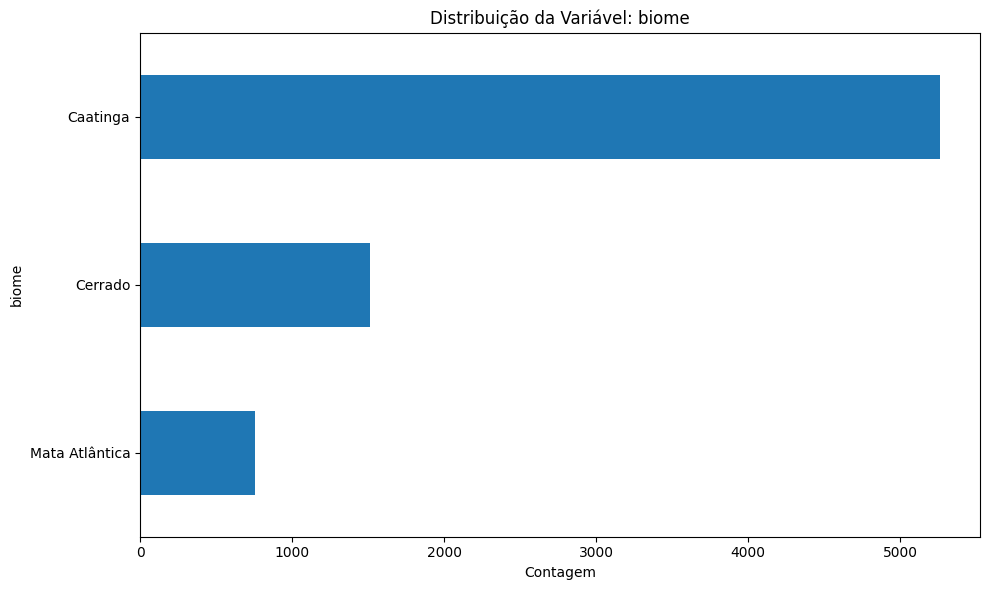

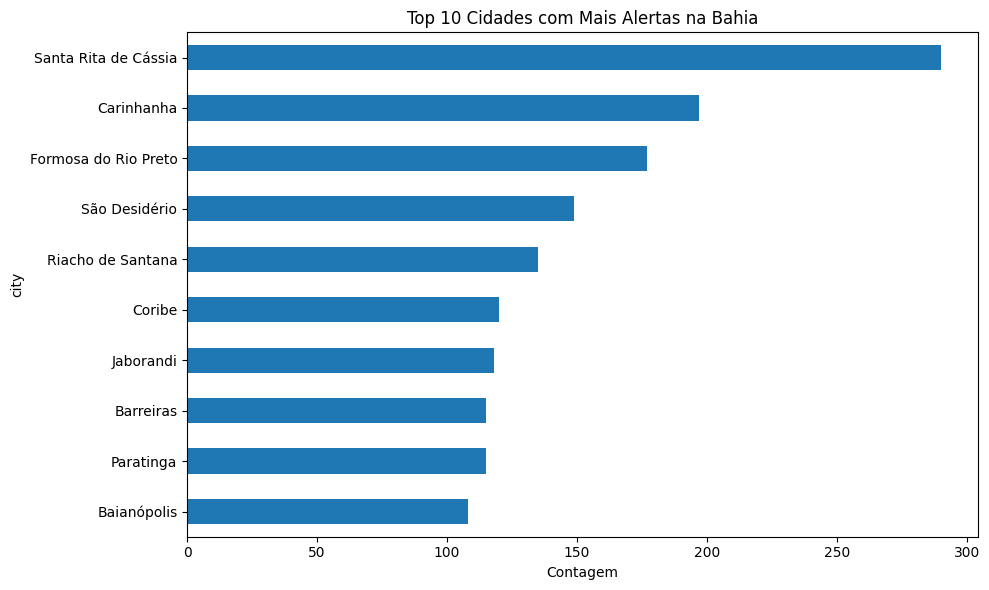

In [ ]:
'''#  Distribuicao categorica tradicional
plt.figure(figsize=(10,6))
base_car['car_code'].value_counts().plot(kind='bar', rot=0)
plt.title('Distribuição de Estado')
plt.xlabel('Estado')
plt.ylabel('Contagem')
plt.tight_layout()
plt.show()'''

# Identificando as colunas categóricas relevantes para visualização
categorical_cols_to_plot = ['biome', 'city']
for col in categorical_cols_to_plot:
    plt.figure(figsize=(10, 6))
    if col == 'city':
        # For 'city', plot only the top 10
        base_car_bahia[col].value_counts().head(10).sort_values(ascending=True).plot(kind='barh')
        plt.title(f'Top 10 Cidades com Mais Alertas na Bahia')
    else:
        # For other categorical columns (like 'biome'), plot all
        base_car_bahia[col].value_counts(ascending=True).plot(kind='barh')
        plt.title(f'Distribuição da Variável: {col}')
    plt.xlabel('Contagem')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

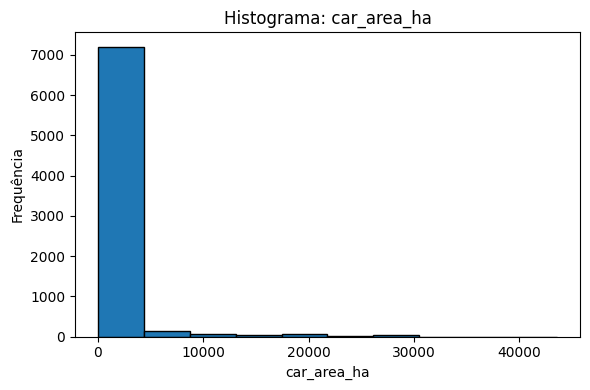

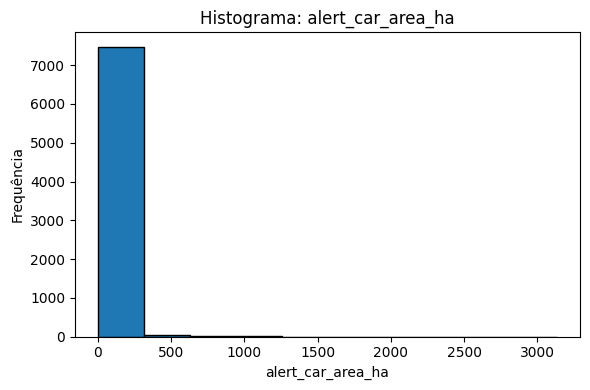

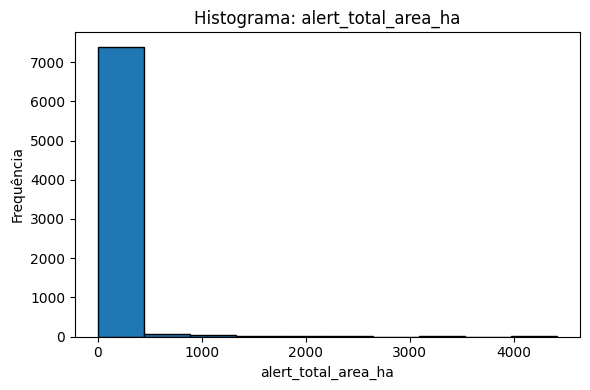

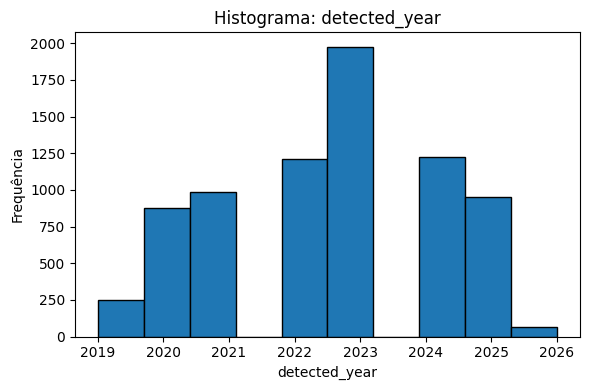

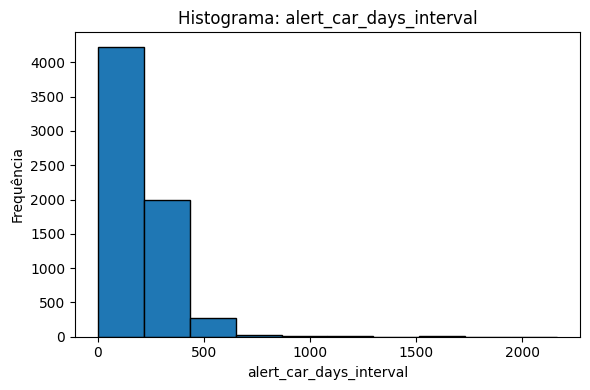

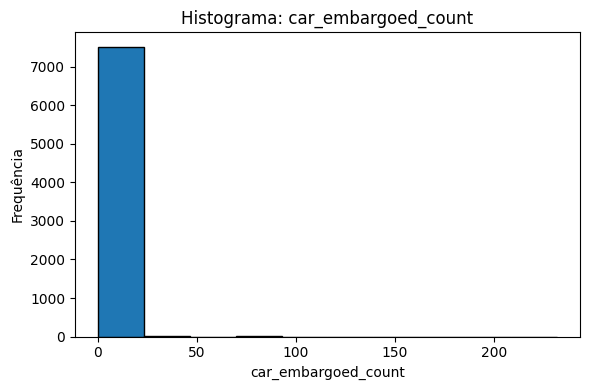

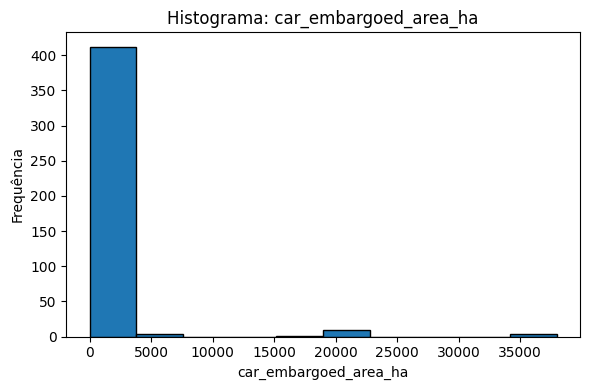

In [ ]:
# DISTRIBUIÇÃO DAS VARIAVEIS NUMERICAS - Histogramas/boxplot

num_cols = ['car_area_ha',
            'alert_car_area_ha',
            'alert_total_area_ha',
            'detected_year',
            'alert_car_days_interval',
            'car_embargoed_count',
            'car_embargoed_area_ha'
            ]
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(base_car_bahia[col].dropna(), bins=10, edgecolor='black')
    plt.title(f'Histograma: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()

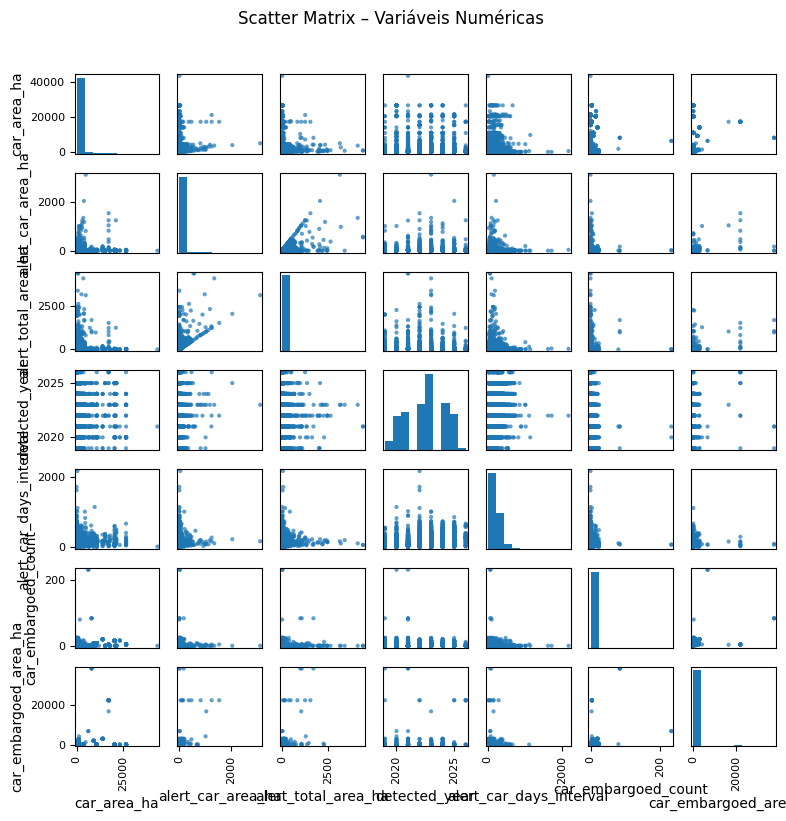

In [ ]:
from pandas.plotting import scatter_matrix

# Scatter Matrix
scatter_matrix(base_car_bahia[num_cols], diagonal='hist', alpha=0.7, figsize=(8,8))
plt.suptitle('Scatter Matrix – Variáveis Numéricas', y=1.02)
plt.tight_layout()
plt.show()

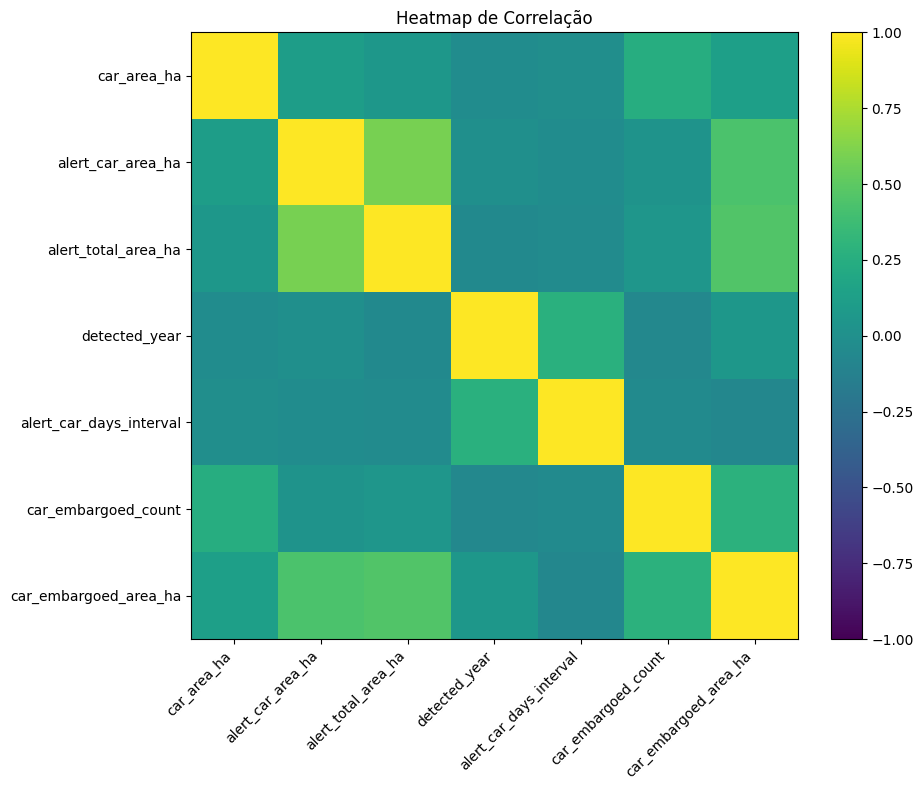

In [ ]:
# Heatmap de correlacao
corr = base_car_bahia[num_cols].corr()
plt.figure(figsize=(10,8))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title('Heatmap de Correlação')
plt.tight_layout()
plt.show()


1. Scatter Matrix
O Scatter Matrix mostra graficamente a relação entre todas as variáveis numéricas.

Cada linha e coluna representa uma variável.

Na diagonal aparecem os histogramas.

Fora da diagonal aparecem os gráficos de dispersão.

Relação entre áreas dos alertas: O gráfico confirma visualmente a forte correlação encontrada no heatmap entre: alert_car_area_ha x alert_total_area_ha. Os pontos formam quase uma reta crescente. Isso demonstra relação linear positiva.


Distribuição das variáveis: Praticamente todas as variáveis apresentam: muitos valores pequenos; poucos valores extremamente altos. Esse comportamento caracteriza uma distribuição assimétrica à direita (right-skewed). É exatamente o que as estatísticas descritivas já haviam mostrado.

Presença de outliers: O Scatter Matrix evidencia vários pontos isolados. Por exemplo: imóveis muito grandes; alertas muito extensos; imóveis com milhares de embargos Esses registros estão muito distantes da maioria dos dados.

Ano de detecção: Como existem poucos anos (2019–2026), os pontos aparecem em faixas horizontais. Isso mostra que a variável é discreta.

Área do imóvel: Observa-se grande concentração de imóveis pequenos. Pouquíssimos imóveis possuem áreas extremamente elevadas.

Embargos: Também existe uma forte concentração próxima de zero. Apenas poucos imóveis apresentam milhares de embargos.



2. Heatmap de Correlação

O heatmap representa a correlação de Pearson, cujo coeficiente varia de -1 a +1.

+1 → correlação positiva perfeita.
0 → praticamente nenhuma relação linear.
-1 → correlação negativa perfeita.

Quanto mais clara (amarela) a célula, maior a correlação positiva.

Principais resultados
Forte correlação entre alert_car_area_ha x alert_total_area_ha. Essa é a relação mais evidente do gráfico.

É esperado, pois: alert_total_area_ha representa a área total do alerta. alert_car_area_ha representa a parte desse alerta que intercepta o imóvel do CAR.

Portanto, quando uma aumenta, a outra também tende a aumentar.

Correlação moderada: Observa-se também correlação relativamente alta entre car_embargoed_count x car_embargoed_area_ha. Faz sentido porque: quanto maior o número de embargos, maior tende a ser a área embargada.

Área do imóvel x car_area_ha apresenta correlação moderada com, car_embargoed_count,car_embargoed_area_ha. Isso sugere que imóveis maiores tendem a possuir maior área embargada e maior quantidade de embargos.

Entretanto, essa relação não é perfeita. Ano de detecção x detected_year possui correlação muito baixa com praticamente todas as variáveis. Isso indica que apenas conhecer o ano não explica o tamanho dos alertas.

Intervalo de dias: alert_car_days_interval também apresenta baixa correlação linear com as demais variáveis.

O que o heatmap indica para o modelo? É um bom sinal.

Não existem muitas variáveis altamente correlacionadas entre si. Isso reduz problemas de multicolinearidade.

A única relação forte observada é: alert_car_area_ha x  alert_total_area_ha que é esperada.

2. Scatter Matrix

Relação entre áreas dos alertas

O gráfico confirma visualmente a forte correlação encontrada no heatmap.

alert_car_area_ha × alert_total_area_ha


Os pontos formam quase uma reta crescente. Isso demonstra relação linear positiva.


Distribuição das variáveis

Praticamente todas as variáveis apresentam: muitos valores pequenos;
poucos valores extremamente altos. Esse comportamento caracteriza uma distribuição assimétrica à direita (right-skewed). É exatamente o que as estatísticas descritivas já haviam mostrado.

Presença de outliers - O Scatter Matrix evidencia vários pontos isolados.

Por exemplo:

imóveis muito grandes;
alertas muito extensos;
imóveis com milhares de embargos.

Esses registros estão muito distantes da maioria dos dados.

Ano de detecção Como existem poucos anos (2019–2026), os pontos aparecem em faixas horizontais. Isso mostra que a variável é discreta.

Área do imóvel

Observa-se grande concentração de imóveis pequenos Pouquíssimos imóveis possuem áreas extremamente elevadas.

Embargos

Também existe uma forte concentração próxima de zero Apenas poucos imóveis apresentam milhares de embargos.

Conclusões da análise gráfica

A análise conjunta do heatmap de correlação e da matriz de dispersão evidencia que a base apresenta baixa correlação linear entre a maioria das variáveis, reduzindo o risco de multicolinearidade durante a modelagem. A exceção é a forte associação entre alert_car_area_ha e alert_total_area_ha, resultado esperado por ambas representarem medidas relacionadas à área dos alertas.

Além disso, os gráficos mostram que as variáveis numéricas possuem distribuições fortemente assimétricas, com elevada concentração de valores baixos e poucos valores extremamente altos (outliers). Esse comportamento é típico de bases ambientais e sugere que, nas etapas de pré-processamento, poderá ser vantajoso aplicar transformações como log1p ou utilizar modelos robustos a distribuições não normais, como Random Forest e XGBoost, que lidam naturalmente com esse tipo de dado sem exigir normalização estrita.

# **# TRATAMENTO DOS DADOS**

Tratamento dos dados (conversão de datas, imputação de ausentes, codificação de categorias e seleção de atributos). Essa sequência segue um fluxo consistente para preparar a base para a modelagem preditiva.

In [ ]:
# Conversão das colunas de data para datetime
base_car_bahia['detected_at'] = pd.to_datetime(base_car_bahia['detected_at'], errors='coerce')
base_car_bahia['alert_car_before_dt'] = pd.to_datetime(base_car_bahia['alert_car_before_dt'], errors='coerce')
base_car_bahia['alert_car_after_dt'] = pd.to_datetime(base_car_bahia['alert_car_after_dt'], errors='coerce')

print("Colunas de data convertidas. Verificando os tipos de dados:")
print(base_car_bahia[['detected_at', 'alert_car_before_dt', 'alert_car_after_dt']].info())

Colunas de data convertidas. Verificando os tipos de dados:
<class 'pandas.core.frame.DataFrame'>
Index: 7534 entries, 1 to 119170
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   detected_at          7534 non-null   datetime64[ns]
 1   alert_car_before_dt  6527 non-null   datetime64[ns]
 2   alert_car_after_dt   6527 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 235.4 KB
None


In [ ]:
# Tratamento em registros Ausentes (Na) com percentual até 5%
# Remover registros pontuais ou realizar imputação simples (média, mediana ou moda).

# Filtrar colunas com até 5% de valores ausentes
low_na_columns = ausente_car[ausente_car['porcentagem_ausentes'] <= 5]

print("Colunas com percentual de valores ausentes de até 5%:")
print(low_na_columns)

Colunas com percentual de valores ausentes de até 5%:
                          contagem_ausentes  porcentagem_ausentes
rural_property_id                         0                   0.0
car_code                                  0                   0.0
car_area_ha                               0                   0.0
alert_car_area_ha                         0                   0.0
alert_total_area_ha                       0                   0.0
alert_id                                  0                   0.0
alert_code                                0                   0.0
alert_geometry_id                         0                   0.0
source                                    0                   0.0
detected_year                             0                   0.0
detected_at                               0                   0.0
biome_id                                  0                   0.0
biome                                     0                   0.0
state_id              

In [ ]:
# Remover colunas de identificadores que não agregam informação para o modelo

# A resposta é: nem todo campo que termina em _id deve ser removido. É preciso entender a função de cada identificador 'rural_property_id', 'car_code','alert_id', 'alert_code' 'alert_geometry_id'.
#Isso não significa que essas colunas serão usadas no modelo.
# Quando remover os IDs? Na construção do modelo, após a EDA e antes da seleção de atributos.

columns_to_drop = [
    'biome_id',
    'state_id',
    'city_id'
]

if columns_to_drop:
    base_car = base_car_bahia.drop(columns=columns_to_drop)
    print(f"Colunas removidas: {columns_to_drop}")
else:
    print("Nenhuma das colunas de identificadores especificadas foi encontrada para remoção.")

print("Dimensão da base após remoção de identificadores:")
display(base_car_bahia.shape)

Colunas removidas: ['biome_id', 'state_id', 'city_id']
Dimensão da base após remoção de identificadores:


(7534, 49)

In [ ]:
# verificar colunas com percentual entre 0,0001 e 5%

low_na_columns = ausente_car[(ausente_car['porcentagem_ausentes'] > 0.00001) & (ausente_car['porcentagem_ausentes'] <= 5)]

print("Colunas com percentual de valores ausentes entre 0.00001% e 5%:")
print(low_na_columns)

Colunas com percentual de valores ausentes entre 0.00001% e 5%:
Empty DataFrame
Columns: [contagem_ausentes, porcentagem_ausentes]
Index: []


In [ ]:
# Identificar colunas com percentual de valores ausentes entre 5% e 30%
columns_to_impute = ausente_car[
    (ausente_car['porcentagem_ausentes'] > 5) &
    (ausente_car['porcentagem_ausentes'] <= 30)
].index.tolist()

print(f"Colunas identificadas para imputação (5%-30% ausentes): {columns_to_impute}")



Colunas identificadas para imputação (5%-30% ausentes): ['alert_car_before_dt', 'alert_car_after_dt', 'alert_car_days_interval']


In [ ]:
# Alteração nas colunas com ausente entre 5 e 30%

if columns_to_impute:
    print(f"Iniciando imputação para colunas com 5%-30% ausentes: {columns_to_impute}")

    # Separar colunas por tipo para imputação mais clara
    datetime_cols = [col for col in columns_to_impute if pd.api.types.is_datetime64_any_dtype(base_car_bahia[col])]
    numeric_cols = [col for col in columns_to_impute if pd.api.types.is_numeric_dtype(base_car_bahia[col])]

    # Parte 1: Imputação de colunas datetime
    if datetime_cols:
        print("\nImputando colunas de data:")
        for col in datetime_cols:
            median_date = base_car_bahia[col].median()
            base_car_bahia[col] = base_car_bahia[col].fillna(median_date)
            print(f"   - Coluna '{col}' (datetime) imputada com a mediana: {median_date.strftime('%Y-%m-%d')}")

    # Parte 2: Imputação de colunas numéricas
    if numeric_cols:
        print("\nImputando colunas numéricas:")
        for col in numeric_cols:
            median_value = base_car_bahia[col].median()
            base_car_bahia[col] = base_car_bahia[col].fillna(median_value)
            print(f"   - Coluna '{col}' (numérica) imputada com a mediana: {median_value}")

    # Verificar valores ausentes após imputação de ambos os tipos
    print("\nVerificando valores ausentes após imputação:")
    new_na_counts = base_car_bahia[columns_to_impute].isnull().sum()
    print(new_na_counts)
else:
    print("Nenhuma coluna encontrada com percentual de valores ausentes entre 5% e 30%.")

Iniciando imputação para colunas com 5%-30% ausentes: ['alert_car_before_dt', 'alert_car_after_dt', 'alert_car_days_interval']

Imputando colunas de data:
   - Coluna 'alert_car_before_dt' (datetime) imputada com a mediana: 2022-12-28
   - Coluna 'alert_car_after_dt' (datetime) imputada com a mediana: 2023-05-13

Imputando colunas numéricas:
   - Coluna 'alert_car_days_interval' (numérica) imputada com a mediana: 162.0

Verificando valores ausentes após imputação:
alert_car_before_dt        0
alert_car_after_dt         0
alert_car_days_interval    0
dtype: int64


In [ ]:
# Identificar colunas com percentual de valores ausentes acima de 30%
columns_to_impute_with_zero = ausente_car[
    (ausente_car['porcentagem_ausentes'] > 30)
].index.tolist()

print(f"Colunas identificadas para imputação com zero (>30% ausentes): {columns_to_impute_with_zero}")


Colunas identificadas para imputação com zero (>30% ausentes): ['legal_reserve_area_ha', 'alert_legal_reserve_area_ha', 'ppa_area_ha', 'alert_ppa_area_ha', 'alert_car_uc_id', 'alert_car_uc_unit', 'alert_car_uc_area_ha', 'alert_car_indigenous_land_id', 'alert_car_indigenous_land', 'alert_car_indigenous_area_ha', 'alert_car_quilombo_id', 'alert_car_quilombo', 'alert_car_quilombo_area', 'alert_car_settlements_id', 'alert_car_settlements', 'alert_car_settlements_area_ha', 'alert_car_uas_area_ha', 'alert_car_asv_area_ha', 'alert_car_pmfs_area_ha', 'alert_car_poa_area_ha', 'alert_car_efp_area_ha', 'car_embargoed_area_ha']


In [ ]:
# Alteração nas colunas com ausente acima de 30%

if columns_to_impute_with_zero:
    print(f"Iniciando imputação para colunas com mais de 30% ausentes (preenchimento com 0): {columns_to_impute_with_zero}")

    for col in columns_to_impute_with_zero:
        # Preencher valores ausentes com 0
        base_car_bahia[col] = base_car_bahia[col].fillna(0)
        print(f"   - Coluna '{col}' imputada com 0.")

    # Verificar valores ausentes após imputação
    print("\nVerificando valores ausentes após imputação com zero:")
    new_na_counts_zero = base_car_bahia[columns_to_impute_with_zero].isnull().sum()
    print(new_na_counts_zero)
else:
    print("Nenhuma coluna encontrada com percentual de valores ausentes acima de 30%.")

Iniciando imputação para colunas com mais de 30% ausentes (preenchimento com 0): ['legal_reserve_area_ha', 'alert_legal_reserve_area_ha', 'ppa_area_ha', 'alert_ppa_area_ha', 'alert_car_uc_id', 'alert_car_uc_unit', 'alert_car_uc_area_ha', 'alert_car_indigenous_land_id', 'alert_car_indigenous_land', 'alert_car_indigenous_area_ha', 'alert_car_quilombo_id', 'alert_car_quilombo', 'alert_car_quilombo_area', 'alert_car_settlements_id', 'alert_car_settlements', 'alert_car_settlements_area_ha', 'alert_car_uas_area_ha', 'alert_car_asv_area_ha', 'alert_car_pmfs_area_ha', 'alert_car_poa_area_ha', 'alert_car_efp_area_ha', 'car_embargoed_area_ha']
   - Coluna 'legal_reserve_area_ha' imputada com 0.
   - Coluna 'alert_legal_reserve_area_ha' imputada com 0.
   - Coluna 'ppa_area_ha' imputada com 0.
   - Coluna 'alert_ppa_area_ha' imputada com 0.
   - Coluna 'alert_car_uc_id' imputada com 0.
   - Coluna 'alert_car_uc_unit' imputada com 0.
   - Coluna 'alert_car_uc_area_ha' imputada com 0.
   - Coluna '

In [ ]:
new_na_counts = base_car_bahia.isnull().sum()
new_na_pct = (new_na_counts / len(base_car_bahia) * 100).round(2)
final_ausente_car = pd.DataFrame({
    'contagem_ausentes': new_na_counts,
    'porcentagem_ausentes': new_na_pct
})

# Filtrar apenas colunas que ainda possuem valores ausentes (se houver)
columns_with_remaining_na = final_ausente_car[final_ausente_car['contagem_ausentes'] > 0]

if not columns_with_remaining_na.empty:
    print("Colunas com valores ausentes restantes após todas as imputações:")
    display(columns_with_remaining_na)
else:
    print("Nenhum valor ausente restante no DataFrame `base_car_bahia`.")

Nenhum valor ausente restante no DataFrame `base_car_bahia`.


In [ ]:
# Verificar valores únicos em cada coluna categórica

# Identificar todas as colunas categóricas (tipo 'object')
categorical_columns = base_car_bahia.select_dtypes(include='object').columns.tolist()

print("\n--- Análise de Valores Únicos em Colunas Categóricas ---\n")

for col in categorical_columns:
    unique_values_count = base_car_bahia[col].nunique()
    print(f"Coluna '{col}': {unique_values_count} valores únicos")
    # Para evitar imprimir listas muito longas, exibimos os valores únicos apenas se houver poucos
    if unique_values_count < 50:
        print(f"   Valores únicos: {base_car_bahia[col].unique().tolist()}")
    else:
        print("   (Muitos valores únicos para exibir. Exibindo os 5 mais frequentes:)")
        print(f"   {base_car_bahia[col].value_counts().head(5).index.tolist()}")
    print("\n")


--- Análise de Valores Únicos em Colunas Categóricas ---

Coluna 'car_code': 5402 valores únicos
   (Muitos valores únicos para exibir. Exibindo os 5 mais frequentes:)
   ['BA-2928406-F5BC107FEF394D248CE45C1EE95BF3B6', 'BA-2909208-DE670BB2028443C7B79BEC10C5552F68', 'BA-2930154-EE12DCBDD2D34CEE9C2274987D30FFFE', 'BA-2907103-258248E29E4449CE986167C5CF18BE21', 'BA-2930758-8035B46A365F4DD38B2CD56F27930FBF']


Coluna 'source': 36 valores únicos
   Valores únicos: ['{SAD-CAATINGA}', '{SAD-MATA-ATLANTICA}', '{DETERB-AMAZONIA,DETER-CERRADO,SAD-CERRADO}', '{DETER-CERRADO,SAD-CERRADO}', '{DETER-CERRADO}', '{DETER-CERRADO,SAD-CAATINGA}', '{PRODES-CERR}', '{SOS-INPE}', '{GLAD,SAD-CAATINGA}', '{GLAD,SOS-INPE}', '{GLAD}', '{DETER-CERRADO,GLAD}', '{DETER-CERRADO,PRODES-CERR}', '{SAD-CAATINGA,SAD-MATA-ATLANTICA}', '{GLAD,PRODES-CERR}', '{GLAD,SAD-MATA-ATLANTICA}', '{SAD-CERRADO}', '{DETER-CERRADO,SAD-CAATINGA,SAD-CERRADO}', '{PRODES-MATA-ATLANTICA}', '{PRODES-CAATINGA}', '{SAD-CAATINGA,SAD-CERRADO}',

Análise das Variáveis Categóricas

A análise das variáveis categóricas teve como objetivo identificar o grau de diversidade das categorias presentes na base e avaliar sua relevância para as etapas de codificação e modelagem preditiva. Foram analisadas as principais variáveis nominais relacionadas aos imóveis rurais, localização geográfica, origem dos alertas e sobreposição com áreas protegidas.

Observou-se que algumas variáveis apresentam baixa cardinalidade, contendo poucas categorias distintas, enquanto outras possuem alta cardinalidade, com centenas ou milhares de valores únicos. Essa característica deverá ser considerada durante a etapa de engenharia de atributos, uma vez que influencia diretamente a estratégia de codificação das variáveis para utilização em algoritmos de aprendizado de máquina.

Identificação dos imóveis (car_code)

A variável car_code apresenta 48.929 valores únicos, evidenciando que os 68.697 alertas analisados estão distribuídos entre aproximadamente 49 mil imóveis rurais distintos. Isso indica que um mesmo imóvel pode estar associado a múltiplos alertas de desmatamento ao longo do período analisado, característica importante para estudos de recorrência e criticidade ambiental.

Fonte dos alertas (source)

A variável source possui 51 categorias distintas, representando diferentes sistemas de monitoramento utilizados para identificar os alertas de desmatamento.

As fontes mais frequentes incluem:

{SAD-CAATINGA}
{DETER-CERRADO,SAD-CERRADO}
{GLAD}
{PRODES-CERR}
{DETER-CERRADO}

A diversidade de fontes demonstra que a base integra informações provenientes de diferentes programas de monitoramento remoto, ampliando a cobertura espacial e temporal dos eventos registrados.

Bioma (biome)

A variável biome apresenta apenas três categorias, correspondentes aos biomas existentes no território baiano:

Caatinga;
Mata Atlântica;
Cerrado.

A baixa cardinalidade dessa variável facilita sua utilização direta em modelos de aprendizado de máquina, além de permitir análises comparativas entre diferentes contextos ambientais.

Estado (state)

A variável state apresenta apenas uma categoria (Bahia), resultado do recorte espacial adotado neste estudo.

Por não possuir variabilidade, essa variável não contribui para discriminar os registros e poderá ser removida durante a etapa de preparação dos dados, evitando redundância na modelagem.

Municípios (city)

A variável city possui 418 municípios distintos, representando praticamente todo o território baiano.

Os municípios com maior frequência de registros incluem:

Santa Rita de Cássia;
Formosa do Rio Preto;
São Desidério;
Carinhanha;
Riacho de Santana.

Essa elevada cardinalidade reflete a ampla distribuição espacial dos alertas e deverá ser considerada na estratégia de codificação da variável, uma vez que métodos tradicionais de One-Hot Encoding podem aumentar significativamente a dimensionalidade da base.

Unidades de Conservação (alert_car_uc_unit)

Foram identificadas 65 categorias distintas relacionadas às Unidades de Conservação.

A categoria 0 é a mais frequente, indicando ausência de sobreposição com Unidades de Conservação para a maioria dos registros. Entre as unidades identificadas destacam-se:

Área de Proteção Ambiental do Rio Preto;
Área de Proteção Ambiental Lago de Sobradinho;
Área de Proteção Ambiental Dunas e Veredas do Baixo Médio São Francisco;
Área de Proteção Ambiental Bacia do Rio de Janeiro.

Esse comportamento demonstra que apenas uma parcela reduzida dos alertas ocorre dentro ou em áreas de influência dessas unidades.

Terras Indígenas (alert_car_indigenous_land)

A variável apresenta apenas sete categorias, incluindo a categoria 0, que representa ausência de sobreposição.

Entre as Terras Indígenas identificadas destacam-se:

Barra Velha do Monte Pascoal;
Tupinambá de Olivença;
Comexatibá;
Massacará;
Tumbalalá;
Fazenda Sítio.

O reduzido número de categorias confirma que a sobreposição dos alertas com Terras Indígenas é pouco frequente na base analisada.

Territórios Quilombolas (alert_car_quilombo)

Foram identificadas 30 categorias distintas, sendo novamente a categoria 0 predominante.

Entre os territórios quilombolas presentes na base destacam-se:

Juá-Bandeira;
Parateca e Pau D'Arco;
Morro Redondo;
Serra da Guia;
Rio das Rãs;
Tijuaçu.

Apesar da diversidade de comunidades identificadas, a quantidade de registros associados a essa variável é reduzida quando comparada ao total da base.

Assentamentos Rurais (alert_car_settlements)

A variável apresenta 319 categorias distintas, incluindo diversos Projetos de Assentamento distribuídos pelo estado.

Os registros mais frequentes incluem:

PA Angical I;
PA Dom Ricardo;
PA Extrativista São Francisco;
PA Rio de Ondas.

Embora apresente alta cardinalidade, a maioria dos registros da base não possui sobreposição com assentamentos rurais.

Considerações para a modelagem

A análise das variáveis categóricas evidencia diferentes níveis de cardinalidade que deverão ser considerados durante a preparação dos dados. As variáveis biome e state possuem baixa cardinalidade, sendo facilmente codificadas para utilização pelos algoritmos de aprendizado de máquina. Em contrapartida, variáveis como car_code, city, alert_car_settlements e source apresentam elevado número de categorias distintas, tornando recomendável a utilização de técnicas como Frequency Encoding ou Target Encoding, capazes de reduzir a dimensionalidade da base sem perda significativa de informação.

Além disso, observa-se que variáveis como state apresentam apenas uma categoria em todos os registros, não contribuindo para a discriminação dos dados e podendo ser removidas durante a etapa de seleção de atributos. Essa análise fornece uma visão detalhada da diversidade das variáveis categóricas e orienta a escolha das estratégias de codificação mais adequadas para o desenvolvimento do modelo de Random Forest destinado à estimativa do Índice de Criticidade Ambiental (ICA).


## Codificação de Variáveis Categóricas de Baixa Cardinalidade

Vamos aplicar One-Hot Encoding nas colunas,  pois possuem uma baixa quantidade de valores únicos e sua representação como variáveis numéricas binárias pode ser benéfica para o modelo.

In [ ]:
# Colunas de baixa cardinalidade para One-Hot Encoding
low_cardinality_cols = ['source','biome','alert_car_quilombo','alert_car_indigenous_land']

# Aplicar One-Hot Encoding
base_car_bahia = pd.get_dummies(base_car_bahia, columns=low_cardinality_cols, drop_first=True)

print("DataFrame após One-Hot Encoding nas colunas 'biome' e 'state':")
display(base_car_bahia.head())
print("\nNovas dimensões do DataFrame:")
display(base_car_bahia.shape)
print("\nTipos de dados atualizados:")
print(base_car_bahia.info())

DataFrame após One-Hot Encoding nas colunas 'biome' e 'state':


,rural_property_id,car_code,car_area_ha,alert_car_area_ha,alert_total_area_ha,alert_id,alert_code,alert_geometry_id,detected_year,detected_at,...,alert_car_quilombo_BARRA DO PARATECA,alert_car_quilombo_JIBOIA,alert_car_quilombo_JUÁ-BANDEIRA,alert_car_quilombo_MORRO REDONDO,alert_car_quilombo_PARATECA E PAU D'ARCO,alert_car_quilombo_RIO DAS RÃS,alert_car_quilombo_SERRA DA GUIA,alert_car_quilombo_TOMÁS NUNES,alert_car_indigenous_land_Barra Velha do Monte Pascoal,alert_car_indigenous_land_Tupinambá de Olivença
1,8347439,BA-2916500-8C68D146F69C47D6B423D55CD4699C46,3.03066,2.81597,8.1183,700776,700776.0,1092471.0,2022.0,2022-06-01,...,False,False,False,False,False,False,False,False,False,False
7,7858434,BA-2901353-F1134F6535DD4883B0D2E1827E406D53,13.25241,0.04394,2.6057,620677,620677.0,1092655.0,2022.0,2022-04-01,...,False,False,False,False,False,False,False,False,False,False
195,7862531,BA-2930204-357F7C66C5894E6099C5DEF3C91A3BE1,4663.71955,1.61278,1.6128,620305,620305.0,1150130.0,2022.0,2022-04-01,...,False,False,False,False,False,False,False,False,False,False
199,15307166,BA-2918407-E6A43F6976A14BB1BAC8898EA5911EB4,72.19936,0.72579,6.2553,701280,701280.0,1150261.0,2022.0,2022-06-01,...,False,False,False,False,False,False,False,False,False,False
201,7862715,BA-2931905-668A097F1E7D4D9FB616B94C434665C1,9.72091,0.00315,3.4711,701421,701421.0,1150353.0,2022.0,2022-06-01,...,False,False,False,False,False,False,False,False,False,False



Novas dimensões do DataFrame:


(7534, 92)


Tipos de dados atualizados:
<class 'pandas.core.frame.DataFrame'>
Index: 7534 entries, 1 to 119170
Data columns (total 92 columns):
 #   Column                                                           Non-Null Count  Dtype         
---  ------                                                           --------------  -----         
 0   rural_property_id                                                7534 non-null   int64         
 1   car_code                                                         7534 non-null   object        
 2   car_area_ha                                                      7534 non-null   float64       
 3   alert_car_area_ha                                                7534 non-null   float64       
 4   alert_total_area_ha                                              7534 non-null   float64       
 5   alert_id                                                         7534 non-null   int64         
 6   alert_code                                            

A escolha entre OneHotEncoder e LabelEncoder depende da natureza da variável categórica e do algoritmo de Machine Learning que será utilizado.

1. Label Encoding (LabelEncoder):

Atribui um número inteiro único a cada categoria da variável (ex: 'Cerrado': 0, 'Caatinga': 1, 'Amazônia': 2).
Uso: É adequado para variáveis ordinais, onde existe uma ordem intrínseca entre as categorias (ex: 'baixo', 'médio', 'alto'). O modelo pode inferir que 'alto' é maior que 'médio', e 'médio' é maior que 'baixo'.
Problema para variáveis nominais: Se usada em variáveis nominais (onde não há ordem natural, como biome e state), o algoritmo pode erroneamente interpretar que uma categoria é 'maior' ou 'mais importante' que outra devido aos valores numéricos atribuídos. Por exemplo, se 'Cerrado' for codificado como 0 e 'Caatinga' como 1, o modelo pode assumir uma relação ordinal que não existe na realidade.


2. One-Hot Encoding (OneHotEncoder ou pd.get_dummies()):

Cria uma nova coluna binária (0 ou 1) para cada categoria única da variável original. Por exemplo, para biome, teríamos biome_Cerrado, biome_Caatinga, biome_Amazonia, etc.
Uso: É ideal para variáveis nominais, como biome (biomas não têm uma ordem hierárquica intrínseca) e state (estados não são 'maiores' ou 'menores' uns que os outros). Dessa forma, evitamos que o modelo crie uma relação ordinal artificial.
drop_first=True foi utilizado para evitar a multicolinearidade, removendo uma das colunas criadas (a primeira categoria) e representando-a implicitamente quando todas as outras são 0.
Em resumo: Optamos por pd.get_dummies() (que realiza One-Hot Encoding) para as colunas biome e state porque elas são variáveis categóricas nominais. Isso garante que o modelo não atribua uma importância ou ordem incorreta às categorias, o que poderia distorcer os resultados e a interpretação do aprendizado.

Se estivéssemos lidando com uma variável como, por exemplo, 'nível de risco' ('baixo', 'médio', 'alto'), o LabelEncoder poderia ser uma alternativa válida, pois haveria uma ordem clara entre as categorias.

## Codificação de Variáveis Categóricas de Alta Cardinalidade

Vamos aplicar a **Frequency Encoding** (Codificação por Frequência) para colunas selecionadas com alta cardinalidade para reduzir a dimensionalidade e potencialmente capturar a importância da frequência de cada categoria.

In [ ]:
# Colunas de alta cardinalidade para Frequency Encoding
high_cardinality_cols = ['city', 'alert_car_uc_unit']

for col in high_cardinality_cols:
    # Calcular a frequência de cada categoria
    frequency_map = base_car[col].value_counts(normalize=True)
    # Mapear as categorias para suas respectivas frequências
    base_car[f'{col}_freq'] = base_car[col].map(frequency_map)
    # Remover a coluna original
    base_car = base_car.drop(columns=[col])
    print(f"Coluna '{col}' codificada por frequência e removida. Nova coluna: '{col}_freq'")

print("\nDataFrame após Frequency Encoding:")
display(base_car.head())
print("\nNovas dimensões do DataFrame:")
display(base_car.shape)
print("\nTipos de dados atualizados:")
print(base_car.info())

Coluna 'city' codificada por frequência e removida. Nova coluna: 'city_freq'
Coluna 'alert_car_uc_unit' codificada por frequência e removida. Nova coluna: 'alert_car_uc_unit_freq'

DataFrame após Frequency Encoding:


,rural_property_id,car_code,car_area_ha,alert_car_area_ha,alert_total_area_ha,alert_id,alert_code,alert_geometry_id,source,detected_year,...,alert_car_poa_area_ha,alert_car_efp,alert_car_efp_area_ha,car_embargoed_count,car_embargoed_area_ha,alert_car_before_dt,alert_car_after_dt,alert_car_days_interval,city_freq,alert_car_uc_unit_freq
1,8347439,BA-2916500-8C68D146F69C47D6B423D55CD4699C46,3.03066,2.81597,8.1183,700776,700776.0,1092471.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,2022-01-14,2022-06-07,144.0,0.013140,NaN
7,7858434,BA-2901353-F1134F6535DD4883B0D2E1827E406D53,13.25241,0.04394,2.6057,620677,620677.0,1092655.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,2021-10-13,2022-04-09,178.0,0.001327,NaN
195,7862531,BA-2930204-357F7C66C5894E6099C5DEF3C91A3BE1,4663.71955,1.61278,1.6128,620305,620305.0,1150130.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,2019-12-14,2022-03-20,827.0,0.004247,NaN
199,15307166,BA-2918407-E6A43F6976A14BB1BAC8898EA5911EB4,72.19936,0.72579,6.2553,701280,701280.0,1150261.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,2021-10-05,2022-06-28,266.0,0.002124,NaN
201,7862715,BA-2931905-668A097F1E7D4D9FB616B94C434665C1,9.72091,0.00315,3.4711,701421,701421.0,1150353.0,{SAD-CAATINGA},2022.0,...,NaN,0.0,NaN,0.0,NaN,2022-01-12,2022-04-14,92.0,0.004646,NaN



Novas dimensões do DataFrame:


(7534, 46)


Tipos de dados atualizados:
<class 'pandas.core.frame.DataFrame'>
Index: 7534 entries, 1 to 119170
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   rural_property_id              7534 non-null   int64         
 1   car_code                       7534 non-null   object        
 2   car_area_ha                    7534 non-null   float64       
 3   alert_car_area_ha              7534 non-null   float64       
 4   alert_total_area_ha            7534 non-null   float64       
 5   alert_id                       7534 non-null   int64         
 6   alert_code                     7534 non-null   float64       
 7   alert_geometry_id              7534 non-null   float64       
 8   source                         7534 non-null   object        
 9   detected_year                  7534 non-null   float64       
 10  detected_at                    7534 non-null   datetime64[

Para colunas com alta cardinalidade, como source, city, alert_car_uc_unit, alert_car_indigenous_land, alert_car_quilombo e alert_car_settlements, o One-Hot Encoding pode criar um número excessivo de novas colunas, o que pode levar à "maldição da dimensionalidade", aumentar o consumo de memória e o tempo de treinamento do modelo.

Existem diversas estratégias para lidar com variáveis categóricas de alta cardinalidade, dependendo do contexto e do algoritmo de Machine Learning que será utilizado:

Frequency Encoding (Codificação por Frequência/Contagem): Substitui cada categoria pela sua frequência de ocorrência (contagem ou proporção) no conjunto de dados. Categorias mais comuns terão valores mais altos. É simples e útil, mas categorias com a mesma frequência terão o mesmo valor, perdendo distinção.

Target Encoding (Codificação por Média do Target): Substitui cada categoria pela média da variável alvo para aquela categoria. É muito poderoso, mas exige cuidado para evitar vazamento de dados (data leakage), geralmente usando validação cruzada.

Hashing Encoding (Codificação por Hashing): Transforma as categorias em um número fixo de colunas usando uma função de hashing. Pode resultar em colisões (categorias diferentes recebem o mesmo valor codificado), mas é eficiente para controlar a dimensionalidade.

Agrupamento de Categorias Raras: Agrupa categorias que ocorrem com pouca frequência em uma única categoria, como 'Outros'. Isso reduz a cardinalidade, mas pode perder informações se as categorias raras forem importantes.
Feature Embedding (Incorporação de Características): Mais comum em modelos de Deep Learning, onde cada categoria é mapeada para um vetor de números reais de baixa dimensão, e esses vetores são aprendidos durante o treinamento do modelo.

Para começar, sugiro aplicar a Frequency Encoding em algumas dessas colunas de alta cardinalidade, como source e city, por ser uma técnica relativamente simples e que pode capturar a importância da frequência das categorias. Isso nos dará uma ideia de como o modelo pode reagir a essa transformação.

### Agrupando Categorias Raras em `alert_car_settlements`

Para a coluna `alert_car_settlements`, que possui alta cardinalidade e muitos valores raros, vamos agrupar as categorias que aparecem com pouca frequência em uma única categoria 'Outros'. Isso ajuda a simplificar a variável, mantendo as informações das categorias mais significativas.

In [ ]:
# Analisar a distribuição da coluna 'alert_car_settlements' antes do agrupamento
print("Distribuição original da coluna 'alert_car_settlements':")
print(base_car_bahia['alert_car_settlements'].value_counts(normalize=True).head(10))

# Definir um limite de frequência para considerar uma categoria 'rara' (ex: categorias que representam menos de 1% dos dados)
threshold = 0.01

# Identificar categorias raras
value_counts = base_car_bahia['alert_car_settlements'].value_counts(normalize=True)
rare_categories = value_counts[value_counts < threshold].index

# Substituir as categorias raras por 'Outros'
base_car_bahia['alert_car_settlements'] = base_car_bahia['alert_car_settlements'].replace(rare_categories, 'Outros')

print(f"\nCategorias com frequência abaixo de {threshold*100}% foram agrupadas em 'Outros'.")
print(f"Número de valores únicos antes: {len(value_counts)}")
print(f"Número de valores únicos depois: {base_car_bahia['alert_car_settlements'].nunique()}")

# Analisar a distribuição da coluna 'alert_car_settlements' após o agrupamento
print("\nDistribuição da coluna 'alert_car_settlements' após agrupamento de raras:")
print(base_car_bahia['alert_car_settlements'].value_counts(normalize=True).head(10))

# Verificar o tipo de dados e as primeiras linhas do DataFrame
print("\nVerificando os tipos de dados e as primeiras linhas após a transformação:")
display(base_car_bahia[['alert_car_settlements']].head())
print(base_car_bahia['alert_car_settlements'].info())

Distribuição original da coluna 'alert_car_settlements':
alert_car_settlements
0                                0.903371
PA SENHOR DO BONFIM              0.007168
PA ROMPE GIBAO                   0.005575
PA ANGICAL I                     0.005044
PA EXTRATIVISTA SÃO FRANCISCO    0.005044
PA BRASILANDIA                   0.004646
PA FAZ SANTA HELENA              0.004115
PA VALE VERDE                    0.003849
PA GERAL PITUBA                  0.003186
PA ARIZONA E OUTRAS              0.002655
Name: proportion, dtype: float64

Categorias com frequência abaixo de 1.0% foram agrupadas em 'Outros'.
Número de valores únicos antes: 119
Número de valores únicos depois: 2

Distribuição da coluna 'alert_car_settlements' após agrupamento de raras:
alert_car_settlements
0         0.903371
Outros    0.096629
Name: proportion, dtype: float64

Verificando os tipos de dados e as primeiras linhas após a transformação:


,alert_car_settlements
1,0
7,0
195,Outros
199,0
201,0


<class 'pandas.core.series.Series'>
Index: 7534 entries, 1 to 119170
Series name: alert_car_settlements
Non-Null Count  Dtype 
--------------  ----- 
7534 non-null   object
dtypes: object(1)
memory usage: 117.7+ KB
None


### Codificação das Variáveis Categóricas Restantes

Com a coluna `alert_car_settlements` simplificada, agora vamos aplicar as estratégias de codificação para as variáveis categóricas restantes:

*   **One-Hot Encoding** para `alert_car_settlements` (agora de baixa cardinalidade).
*   **Frequency Encoding** para `alert_car_uc_unit`, `alert_car_indigenous_land` e `alert_car_quilombo` (de alta cardinalidade).

In [ ]:
import pandas as pd

# 1. One-Hot Encoding para 'alert_car_settlements' (agora de baixa cardinalidade)
settlements_col = 'alert_car_settlements'
if settlements_col in base_car_bahia.columns:
    print(f"Aplicando One-Hot Encoding para '{settlements_col}'...")
    base_car_bahia = pd.get_dummies(base_car_bahia, columns=[settlements_col], prefix='settlement', drop_first=True)
    print(f"'{settlements_col}' One-Hot Encoded. Novas colunas:")
    print([col for col in base_car_bahia.columns if 'settlement_' in col])
else:
    print(f"Coluna '{settlements_col}' não encontrada, pulando One-Hot Encoding.")


# Definir as colunas restantes de alta cardinalidade para Frequency Encoding
# Ajustado: 'alert_car_indigenous_land' e 'alert_car_quilombo' já foram OHE em 'be4864cc'
high_cardinality_remaining_cols = ['alert_car_uc_unit']

for col in high_cardinality_remaining_cols:
    if col in base_car_bahia.columns: # Verifique se a coluna ainda existe
        print(f"\nAplicando Frequency Encoding para '{col}'...")
        frequency_map = base_car_bahia[col].value_counts(normalize=True)
        base_car_bahia[f'{col}_freq'] = base_car_bahia[col].map(frequency_map)
        base_car_bahia = base_car_bahia.drop(columns=[col])
        print(f"Coluna '{col}' codificada por frequência e removida. Nova coluna: '{col}_freq'")
    else:
        print(f"\nColuna '{col}' não encontrada no DataFrame, pulando Frequency Encoding.")


print("\n--- Verificação Final --- ")
print("Dimensões do DataFrame após todas as codificações:")
display(base_car_bahia.shape)

print("Primeiras linhas do DataFrame com as novas colunas:")
display(base_car_bahia.head())

print("Tipos de dados atualizados:")
print(base_car_bahia.info())

Aplicando One-Hot Encoding para 'alert_car_settlements'...
'alert_car_settlements' One-Hot Encoded. Novas colunas:
['settlement_Outros']

Aplicando Frequency Encoding para 'alert_car_uc_unit'...
Coluna 'alert_car_uc_unit' codificada por frequência e removida. Nova coluna: 'alert_car_uc_unit_freq'

--- Verificação Final --- 
Dimensões do DataFrame após todas as codificações:


(7534, 92)

Primeiras linhas do DataFrame com as novas colunas:


,rural_property_id,car_code,car_area_ha,alert_car_area_ha,alert_total_area_ha,alert_id,alert_code,alert_geometry_id,detected_year,detected_at,...,alert_car_quilombo_JUÁ-BANDEIRA,alert_car_quilombo_MORRO REDONDO,alert_car_quilombo_PARATECA E PAU D'ARCO,alert_car_quilombo_RIO DAS RÃS,alert_car_quilombo_SERRA DA GUIA,alert_car_quilombo_TOMÁS NUNES,alert_car_indigenous_land_Barra Velha do Monte Pascoal,alert_car_indigenous_land_Tupinambá de Olivença,settlement_Outros,alert_car_uc_unit_freq
1,8347439,BA-2916500-8C68D146F69C47D6B423D55CD4699C46,3.03066,2.81597,8.1183,700776,700776.0,1092471.0,2022.0,2022-06-01,...,False,False,False,False,False,False,False,False,False,0.929121
7,7858434,BA-2901353-F1134F6535DD4883B0D2E1827E406D53,13.25241,0.04394,2.6057,620677,620677.0,1092655.0,2022.0,2022-04-01,...,False,False,False,False,False,False,False,False,False,0.929121
195,7862531,BA-2930204-357F7C66C5894E6099C5DEF3C91A3BE1,4663.71955,1.61278,1.6128,620305,620305.0,1150130.0,2022.0,2022-04-01,...,False,False,False,False,False,False,False,False,True,0.929121
199,15307166,BA-2918407-E6A43F6976A14BB1BAC8898EA5911EB4,72.19936,0.72579,6.2553,701280,701280.0,1150261.0,2022.0,2022-06-01,...,False,False,False,False,False,False,False,False,False,0.929121
201,7862715,BA-2931905-668A097F1E7D4D9FB616B94C434665C1,9.72091,0.00315,3.4711,701421,701421.0,1150353.0,2022.0,2022-06-01,...,False,False,False,False,False,False,False,False,False,0.929121


Tipos de dados atualizados:
<class 'pandas.core.frame.DataFrame'>
Index: 7534 entries, 1 to 119170
Data columns (total 92 columns):
 #   Column                                                           Non-Null Count  Dtype         
---  ------                                                           --------------  -----         
 0   rural_property_id                                                7534 non-null   int64         
 1   car_code                                                         7534 non-null   object        
 2   car_area_ha                                                      7534 non-null   float64       
 3   alert_car_area_ha                                                7534 non-null   float64       
 4   alert_total_area_ha                                              7534 non-null   float64       
 5   alert_id                                                         7534 non-null   int64         
 6   alert_code                                             

In [ ]:
#### Criar atributos agregados por imóvel
## Essas variáveis resumem o histórico de cada imóvel e são muito mais informativas do que o identificador.


# Quantidade de alertas por imóvel
base_car_bahia["car_alert_count"] = (
    base_car_bahia.groupby("car_code")["alert_id"]
      .transform("count")
)

# Área total dos alertas por imóvel
base_car_bahia["car_total_alert_area"] = (
    base_car_bahia.groupby("car_code")["alert_car_area_ha"]
      .transform("sum")
)

# Área média dos alertas por imóvel
base_car_bahia["car_mean_alert_area"] = (
    base_car_bahia.groupby("car_code")["alert_car_area_ha"]
      .transform("mean")
)

# Maior alerta registrado no imóvel
base_car_bahia["car_max_alert_area"] = (
    base_car_bahia.groupby("car_code")["alert_car_area_ha"]
      .transform("max")
)

# Tempo médio entre alertas
base_car_bahia["car_mean_days_interval"] = (
    base_car_bahia.groupby("car_code")["alert_car_days_interval"]
      .transform("mean")
)

### Remoção de Colunas Identificadoras Finais

Agora que o pré-processamento das variáveis categóricas está completo, vamos remover as colunas de identificação restantes que não agregam valor preditivo ao modelo. Estas colunas incluem `rural_property_id`, `car_code`, `alert_id`, `alert_code` e `alert_geometry_id`.

In [ ]:
# Guardar os identificadores para análise posterior
ids = base_car[
    ["rural_property_id", "car_code", "alert_id", "alert_geometry_id"]
].copy()

# Remover do conjunto que será usado no modelo

base_car = base_car_bahia.drop(columns=["rural_property_id", "car_code", "alert_id", "alert_geometry_id"])

print("IDs guardados para análise posterior:")

cols_drop = [
    "rural_property_id",
    "car_code",
    "alert_id",
    "alert_code",
    "alert_geometry_id"
]

base_car_bahia.drop(columns=cols_drop, inplace=True)

print(ids.head())




IDs guardados para análise posterior:
     rural_property_id                                     car_code  alert_id  \
1              8347439  BA-2916500-8C68D146F69C47D6B423D55CD4699C46    700776   
7              7858434  BA-2901353-F1134F6535DD4883B0D2E1827E406D53    620677   
195            7862531  BA-2930204-357F7C66C5894E6099C5DEF3C91A3BE1    620305   
199           15307166  BA-2918407-E6A43F6976A14BB1BAC8898EA5911EB4    701280   
201            7862715  BA-2931905-668A097F1E7D4D9FB616B94C434665C1    701421   

     alert_geometry_id  
1            1092471.0  
7            1092655.0  
195          1150130.0  
199          1150261.0  
201          1150353.0  


In [ ]:
display(base_car_bahia.head())

,car_area_ha,alert_car_area_ha,alert_total_area_ha,detected_year,detected_at,biome_id,state_id,state,city_id,city,...,alert_car_quilombo_TOMÁS NUNES,alert_car_indigenous_land_Barra Velha do Monte Pascoal,alert_car_indigenous_land_Tupinambá de Olivença,settlement_Outros,alert_car_uc_unit_freq,car_alert_count,car_total_alert_area,car_mean_alert_area,car_max_alert_area,car_mean_days_interval
1,3.03066,2.81597,8.1183,2022.0,2022-06-01,36683.0,18398.0,BAHIA,17761.0,Itapicuru,...,False,False,False,False,0.929121,2,2.82640,1.41320,2.81597,216.500000
7,13.25241,0.04394,2.6057,2022.0,2022-04-01,36683.0,18398.0,BAHIA,17052.0,Andorinha,...,False,False,False,False,0.929121,1,0.04394,0.04394,0.04394,178.000000
195,4663.71955,1.61278,1.6128,2022.0,2022-04-01,36683.0,18398.0,BAHIA,19336.0,Sento Sé,...,False,False,False,True,0.929121,3,3.32460,1.10820,1.61278,635.333333
199,72.19936,0.72579,6.2553,2022.0,2022-06-01,36683.0,18398.0,BAHIA,17137.0,Juazeiro,...,False,False,False,False,0.929121,2,16.87120,8.43560,16.14541,411.000000
201,9.72091,0.00315,3.4711,2022.0,2022-06-01,36683.0,18398.0,BAHIA,18954.0,Tucano,...,False,False,False,False,0.929121,1,0.00315,0.00315,0.00315,92.000000


Bem, analisando as colunas restantes no seu base_carDataFrame, existem várias possibilidades para uma variável alvo, dependendo da pergunta específica que você deseja responder com seu modelo.

Aqui estão alguns tipos comuns de alvos que podem ser relevantes no contexto de alertas ambientais, juntamente com possíveis colunas do seu DataFrame:

Classificação binária (prever um resultado 'sim/não'):

settlement_OutrosEsta coluna já existe como um valor booleano ( True/ False) e poderia ser usada para prever se um alerta ocorre em uma das categorias de assentamento menos frequentes. Por exemplo, 'Este alerta está em uma área de assentamento 'Outros'?'
car_embargoed_count(Poderia ser transformado em um alvo binário): Você poderia criar uma nova coluna binária como has_embargo(1 se car_embargoed_count > 0, 0 caso contrário). Isso preveria: 'Este alerta leva a um embargo?'
Regressão (Previsão de um valor numérico):

alert_total_area_haPreveja a área total (em hectares) afetada pelo alerta. Por exemplo: "Qual será a área total afetada pelo alerta?"
alert_car_area_haPreveja a área (em hectares) do alerta que se sobrepõe à propriedade rural (CAR). Por exemplo: "Que porção do alerta estará dentro da propriedade CAR?"
alert_car_days_intervalPreveja a duração do alerta em dias. Por exemplo: "Quantos dias durará este alerta?"
car_embargoed_area_haPreveja a área (em hectares) que estará sob embargo em relação ao alerta. Por exemplo: "Qual será a área total embargada?"


# **### Próximos Passo: Definição do Alvo e Divisão dos Dados**


''### Próximos Passos: Definição do Alvo e Divisão dos Dados

Com todas as etapas de pré-processamento concluídas, o DataFrame `base_car` está pronto para a modelagem de Machine Learning. Os próximos passos são:

1.  **Definir a Variável Alvo (y):** É fundamental identificar qual coluna do `base_car` representa o que você deseja prever (por exemplo, um tipo de alerta, sua severidade, ou a presença de alguma irregularidade).
2.  **Dividir o Dataset em Features (X) e Target (y):** Separar os dados em variáveis independentes (características, `X`) e a variável dependente (alvo, `y`).
3.  **Dividir os Dados em Conjuntos de Treino e Teste:** Utilizar `train_test_split` para criar conjuntos de dados para treinamento e avaliação do modelo, garantindo que o modelo seja testado em dados que não viu durante o treinamento.

In [ ]:
y = base_car_bahia['alert_total_area_ha']
X = base_car_bahia.drop('alert_total_area_ha', axis=1)

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (7534, 91)
Shape of y (target): (7534,)


Now that we have separated the features (`X`) and the target variable (`y`), the next step is to split the data into training and testing sets using `train_test_split`.

In [ ]:
# Faça a separação da base em treino e teste e verifique utilizando shape

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

In [ ]:
# ANALISE DO BALANCEAMENTO

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting the distribution of the target variable 'y'
plt.figure(figsize=(12, 6))
sns.histplot(y, bins=50, kde=True)
plt.title('Distribution of Target Variable: alert_total_area_ha')
plt.xlabel('Alert Total Area (ha)')
plt.ylabel('Count')
plt.xlim(0, y.quantile(0.99)) # Limit x-axis for better visualization due to outliers
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(y), bins=50, kde=True)
plt.title('Distribution of Log1p-transformed Target Variable: alert_total_area_ha')
plt.xlabel('Log1p(Alert Total Area (ha))')
plt.ylabel('Count')
plt.show()


print("\n--- Análise de Balanceamento da Variável Alvo ---")
print("A variável alvo 'alert_total_area_ha' é severamente desbalanceada. Conforme visualizado nos histogramas:")
print("1. O histograma original mostra uma distribuição extremamente assimétrica à direita (right-skewed).")
print("   A grande maioria dos alertas possui áreas totais muito pequenas (próximas de zero),")
print("   enquanto há um número muito pequeno de alertas com áreas extremamente grandes, que são outliers significativos.")
print("   Essa concentração em valores baixos dificulta a visualização e o aprendizado de modelos lineares sem transformação.")
print("2. O histograma da versão log1p-transformada de 'y' mostra uma distribuição mais simétrica, "
      "mas ainda com uma cauda à direita. Isso indica que a transformação logarítmica (log1p) é eficaz para "
      "mitigar a assimetria, mas a natureza dos dados (muitos pequenos, poucos grandes) permanece.")
print("Essa distribuição desbalanceada é comum em dados ambientais e geoespaciais, onde eventos extremos são raros.")
print("Para modelos de regressão, essa assimetria pode levar a:")
print("- Modelos que performam bem para prever áreas pequenas, mas mal para áreas grandes.")
print("- Métricas como o MSE sendo dominada pelos erros de predição dos outliers.")
print("O uso do `RandomForestRegressor` que já escolhemos é uma boa abordagem, pois modelos baseados em árvores são "
      "geralmente mais robustos a distribuições não normais e outliers do que modelos paramétricos. Além disso, "
      "técnicas como a transformação logarítmica da variável alvo (como mostrada no segundo gráfico) podem ser "
      "aplicadas antes do treinamento, ou métricas de avaliação como MAE ou r2_score são mais indicadas para "
      "dados com essa característica.")

Vamos visualizar a distribuição da nossa variável alvo alert_total_area_ha(que é y), para entender seu equilíbrio. Como observado na análise exploratória inicial dos dados, essa variável tende a ser altamente assimétrica. Vou plotar um histograma para mostrar essa distribuição e apresentar minha opinião sobre seu equilíbrio.

A análise confirma que sua variável alvo, alert_total_area_ha, apresenta, de fato, uma assimetria à direita acentuada . Isso significa que há uma alta concentração de pequenas áreas de alerta, com algumas excepcionalmente grandes que atuam como outliers. A log1ptransformação, conforme mostrado no segundo gráfico, ajuda a tornar a distribuição mais simétrica, o que pode ser benéfico para muitos modelos.

Conforme explicado, RandomForestRegressoro método é geralmente robusto a essas distribuições. Embora o Erro Quadrático Médio (EQM) possa ser fortemente influenciado por esses valores discrepantes, o Erro Absoluto Médio (EAM) e o R² costumam ser melhores indicadores de desempenho nesses cenários.

Parece que a célula anterior, que treina e avalia o RandomForestRegressormodelo, foi interrompida. Deseja executar essa célula novamente para concluir o treinamento do modelo e ver suas métricas de avaliação?

In [ ]:
#APLICANDO A TRANSFORMAÇÃO LOG

print("Aplicando a transformação log1p na variável alvo (y_train e y_test)...")

# Aplicar a transformação log1p nas variáveis alvo de treino e teste
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Transformação log1p aplicada com sucesso.")


In [ ]:

print("\n--- Verificando a distribuição da variável alvo após transformação log1p ---")

# Plotando a distribuição de y_train_log
plt.figure(figsize=(12, 6))
sns.histplot(y_train_log, bins=50, kde=True)
plt.title('Distribuição da Variável Alvo Transformada (y_train_log)')
plt.xlabel('Log1p(Alert Total Area (ha)) - Treino')
plt.ylabel('Contagem')
plt.show()

# Plotando a distribuição de y_test_log
plt.figure(figsize=(12, 6))
sns.histplot(y_test_log, bins=50, kde=True)
plt.title('Distribuição da Variável Alvo Transformada (y_test_log)')
plt.xlabel('Log1p(Alert Total Area (ha)) - Teste')
plt.ylabel('Contagem')
plt.show()

print("Os gráficos acima mostram a distribuição da variável alvo após a aplicação da transformação `log1p`.")
print("Essa transformação ajuda a tornar a distribuição mais simétrica, o que é benéfico para a maioria dos modelos de regressão, especialmente aqueles sensíveis a dados altamente assimétricos e outliers. Embora a distribuição não seja perfeitamente normal, ela está significativamente mais 'balanceada' do que a distribuição original, que era fortemente enviesada à direita.")

In [ ]:
'''A transformação `log1p` que você aplicou na sua variável alvo é uma excelente estratégia para lidar com a assimetria e o desequilíbrio na distribuição dos dados em problemas de **regressão**.

No entanto, o SMOTE (Synthetic Minority Over-sampling Technique) é uma técnica especificamente desenvolvida para problemas de **classificação**, onde você tem classes desbalanceadas (por exemplo, muito mais 'não-fraude' do que 'fraude'). O objetivo do SMOTE é criar amostras sintéticas da classe minoritária para equilibrar as classes no conjunto de dados de treino.

Como o seu problema é de **regressão** (prever um valor numérico contínuo como `alert_total_area_ha`), e você já tratou a assimetria com `log1p`, o SMOTE **não é necessário nem apropriado** para este contexto. Para regressão, o 'desbalanceamento' se refere à distribuição dos valores (muitos pequenos, poucos grandes), que é mitigado pela transformação logarítmica e pela robustez de modelos como o `RandomForestRegressor`.

Como saber que um dataset está desbalanceado?
Você sabe que um dataset está desbalanceado quando a distribuição das classes na sua variável alvo (a que você quer prever) não é uniforme, ou seja, uma ou mais classes têm muito menos exemplos do que outras. No seu caso, a variável alvo era Credit Score_High.

Você pode identificar o desbalanceamento de algumas formas:

Contagem de Valores (value_counts()): Como você fez no código, use y_train.value_counts() (ou df['sua_coluna_alvo'].value_counts()). Se uma classe tiver, por exemplo, 70% ou mais dos dados e a outra 30% ou menos, já é um indicativo forte de desbalanceamento.
Porcentagem de Valores (value_counts(normalize=True)): Isso te dá a proporção de cada classe diretamente. No seu caso, você viu que no y_train original, 71% era True e 29% era False para Credit Score_High.
Visualização (Gráficos de Barras): Um gráfico de barras (sns.countplot() ou plt.bar()) da sua variável alvo mostrará visualmente se uma barra é muito mais alta que as outras.
O desbalanceamento é um problema em problemas de classificação, porque modelos de Machine Learning tendem a se tornar "preguiçosos" e aprender a prever a classe majoritária com mais frequência, ignorando a classe minoritária (que muitas vezes é a de maior interesse, como fraude, doença rara, etc.).

Quando aplicar SMOTE?
SMOTE (Synthetic Minority Over-sampling Technique) é uma técnica utilizada exclusivamente para balancear classes em problemas de classificação, especificamente na sua variável alvo (Y). Você o aplica quando:

Você tem um conjunto de dados desbalanceado (conforme descrito acima).
Você está construindo um modelo de classificação (ex: prever se o Credit Score é High ou não).
Seu objetivo é melhorar o desempenho do modelo na previsão da classe minoritária, evitando que o modelo seja viesado em favor da classe majoritária.
O SMOTE funciona criando amostras sintéticas da classe minoritária, não simplesmente duplicando as existentes. Ele "inventa" novos pontos de dados que são semelhantes aos exemplos existentes da classe minoritária, ajudando o modelo a aprender melhor os padrões dessa classe.

Quando aplicar uma Transformação Logarítmica (log1p)?
Uma transformação logarítmica (como np.log1p que é log(1+x)) é utilizada em variáveis numéricas contínuas (X, as suas features), e não na sua variável alvo de classificação. Você a aplica quando:

A distribuição da feature numérica é muito assimétrica (enviesada), geralmente com uma cauda longa para a direita (muitos valores pequenos e poucos valores muito grandes). Ex: renda, gastos, contagem de acessos.
Há a presença de outliers extremos que podem afetar o desempenho do modelo.
Você está usando um modelo que assume que os dados são normalmente distribuídos (ou pelo menos menos assimétricos) ou que é sensível à escala dos dados (ex: regressão linear, alguns modelos baseados em distância).
Seu objetivo é normalizar a distribuição da feature, reduzir o impacto de outliers, e tornar a relação entre variáveis mais linear, o que pode ajudar o modelo a aprender padrões mais robustos.
Em resumo:

SMOTE é para balancear a sua variável alvo categórica em problemas de classificação.
Transformação Logarítmica é para tratar a distribuição de features numéricas contínuas (torná-las menos enviesadas, reduzir outliers) em qualquer tipo de problema de ML.

# **# VERIFICANDO MELHOR MODELO**

Para o seu projeto da EBAC, eu faria uma avaliação comparativa de modelos, em vez de assumir que o Random Forest é a melhor escolha. Isso torna a metodologia mais robusta e fortalece o relatório.

Fluxo recomendado
1. Preparação dos dados
Remover identificadores (car_code, alert_id, etc.).
Tratar valores ausentes.
Aplicar log1p nas variáveis assimétricas (você já fez isso).
Aplicar os encodings definidos (One-Hot, Frequency Encoding).
Separar X e y.
Dividir em treino e teste (train_test_split com stratify=y).
2. Comparar diferentes modelos

Eu compararia pelo menos estes quatro modelos:

Modelo	Testar?	Justificativa
Random Forest	✅ Sim	Forte candidato, robusto a outliers e relações não lineares.
Gradient Boosting	✅ Sim	Bom desempenho em problemas tabulares.
XGBoost ou LightGBM	✅ Se possível	Frequentemente supera Random Forest em bases tabulares.
Regressão Logística	✅ Como baseline	Simples e serve de referência para comparação.

Se o curso da EBAC ainda não abordou XGBoost, pode substituí-lo por HistGradientBoostingClassifier, que já faz parte do scikit-learn.

3. Utilizar Cross Validation?

Sim.

Eu utilizaria Stratified K-Fold Cross Validation, pois sua variável alvo é uma classificação.

StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Isso permite estimar o desempenho médio do modelo em diferentes divisões dos dados e reduz a dependência de uma única partição treino/teste.

4. Quais métricas comparar?

Não utilize apenas acurácia.

Avalie:

Accuracy
Precision
Recall
F1-score
ROC-AUC (se o problema for binário)

Essas métricas fornecem uma visão mais completa, especialmente se houver desbalanceamento entre as classes.

5. Aplicar PCA?

Eu não aplicaria PCA antes do Random Forest.

O PCA reduz a dimensionalidade combinando variáveis em componentes principais. Isso pode ser útil em alguns algoritmos, mas para árvores de decisão geralmente não traz benefícios.

Algoritmo	PCA recomendado?
Regressão Logística	Sim, pode ajudar.
SVM	Sim, em alguns casos.
KNN	Sim, frequentemente melhora o desempenho.
Random Forest	Não é necessário.
XGBoost	Não é necessário.

Além disso, o PCA reduz a interpretabilidade, pois as variáveis originais deixam de existir e são substituídas por componentes.

6. Seleção de atributos

Antes de pensar em PCA, eu faria:

Remoção de identificadores.
Remoção de colunas constantes ou totalmente vazias.
Remoção de atributos redundantes, se necessário.
Avaliação da importância das variáveis após treinar o Random Forest.

Se poucas variáveis concentrarem grande parte da importância, você pode treinar um novo modelo utilizando apenas essas variáveis e comparar o desempenho.

Metodologia que eu adotaria
Preparação dos dados.
Engenharia de atributos.
Divisão treino/teste.
Comparação de modelos com Stratified 5-Fold Cross Validation.
Escolha do melhor modelo com base nas métricas.
Ajuste de hiperparâmetros (GridSearchCV ou RandomizedSearchCV) apenas para o modelo vencedor.
Treinamento final.
Avaliação no conjunto de teste.
Análise da importância das variáveis e interpretação dos resultados.
Minha recomendação para o projeto EBAC

Eu estruturaria o trabalho da seguinte forma:

Etapa	Utilizar?
Random Forest	✅ Sim
Regressão Logística (baseline)	✅ Sim
Gradient Boosting	✅ Sim
XGBoost/LightGBM (se disponível)	✅ Sim
Stratified 5-Fold Cross Validation	✅ Sim
GridSearchCV ou RandomizedSearchCV	✅ Sim, no modelo vencedor
PCA	❌ Não para o Random Forest; só testaria se um modelo linear fosse escolhido
SMOTE	🔍 Avaliar apenas se a variável alvo estiver significativamente desbalanceada

Essa abordagem é metodologicamente sólida, permite justificar a escolha do algoritmo com base em evidências e produz um relatório mais consistente do que simplesmente selecionar o Random Forest desde o início.

With the data now split into training and testing sets, we're ready for the next phase: defining the machine learning pipeline for preprocessing and model training. This will involve handling numerical and categorical features appropriately.

# **### COMPARAÇÃOM ENTRE MODELOS**

You've outlined a great plan for comparing models! However, it seems there might be a small misunderstanding regarding the nature of our target variable. We are currently working on a regression problem because our target, alert_total_area_ha, is a continuous numerical value (area in hectares). The log1p transformation we applied (y_train_log, y_test_log) further confirms this.

For regression problems, metrics like Accuracy, Precision, Recall, F1-score, and ROC-AUC are not appropriate, as they are used for classification. Instead, we should use regression metrics such as:

Mean Absolute Error (MAE): Average of the absolute errors.
Mean Squared Error (MSE): Average of the squared errors.
Root Mean Squared Error (RMSE): Square root of MSE, providing error in the original units.
R-squared (R2): Explains the proportion of variance in the dependent variable that can be predicted from the independent variables.
Similarly, Stratified K-Fold Cross Validation is designed for classification to maintain the proportion of classes across folds. For regression, a standard KFold cross-validation (or RepeatedKFold for more robust estimates) is generally sufficient.

I will now set up a comparison for RandomForestRegressor, GradientBoostingRegressor, XGBoostRegressor, and LinearRegression as a baseline, using KFold cross-validation and the appropriate regression metrics. This will help us identify the best-performing model for predicting alert_total_area_ha.

Import Libraries: Import necessary libraries for model comparison, including regression models, cross-validation, and metrics.
Define Models: Define a set of regression models to compare: Linear Regression (baseline), Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor. Each model will be part of a pipeline with the existing preprocessor.
Setup Cross-Validation: Configure KFold cross-validation strategy suitable for regression problems.
Perform Model Comparison: Iterate through each defined model, perform cross-validation using the preprocessed training data and log-transformed target variable, and collect performance metrics (MAE, MSE, RMSE, R2).
Display Results: Present the cross-validation results for all models in a clear, comparative format.

**Reasoning**:
Importing `LinearRegression`, `GradientBoostingRegressor` from `sklearn.linear_model` and `sklearn.ensemble` respectively, and `KFold` from `sklearn.model_selection` to prepare for model comparison and cross-validation.



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

print("Libraries for Linear Regression, Gradient Boosting Regressor, and KFold imported.")

## Define Models

### Subtask:
Define the regression models to be compared: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor. Each model will be part of a pipeline that includes the existing preprocessor for consistent data transformation.


**Reasoning**:
Import `xgboost` and then initialize the regression models, creating pipelines that incorporate the existing `preprocessor`, and store them in a dictionary as instructed.



In [ ]:
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np # Ensure numpy is imported for select_dtypes

# Identify column types from X_train. X_train is available in the kernel state.
# We assume X_train contains numerical, boolean, datetime, and object columns at this stage.
# The preprocessor will scale numerical, pass through boolean, and drop others.

numeric_features = X_train.select_dtypes(include=np.number).columns
boolean_features = X_train.select_dtypes(include=bool).columns
# Datetime and object features will be dropped by remainder='drop'

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bool', 'passthrough', boolean_features)
    ],
    remainder='drop' # Drop columns not specified in transformers, which include datetime and remaining object columns
)

# 1. Initialize models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
gbr = GradientBoostingRegressor(random_state=42)
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# 2. Create pipelines for each model
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', lr)])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', rf)])

gbr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', gbr)])

xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb_reg)])

# 3. Create a dictionary of models
models = {
    'Linear Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gbr_pipeline,
    'XGBoost': xgb_pipeline
}

print("Regression models initialized and pipelines created:")
for name, model in models.items():
    print(f"- {name} pipeline created: {model}")

# Task
The main task is to develop and evaluate several regression models to predict the 'alert_total_area_ha' based on the preprocessed environmental alert data for the state of Bahia. This involves defining various regression models, setting up a cross-validation strategy, performing a comparative evaluation of these models using relevant metrics, and finally presenting the results.

## Setup Cross-Validation

### Subtask:
Configure the KFold cross-validation strategy for model evaluation.


**Reasoning**:
Instantiate a KFold object to set up the cross-validation strategy with the specified parameters.



In [ ]:
from sklearn.model_selection import KFold

# Configure KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("KFold cross-validation strategy configured:")
print(f"  Number of splits: {kf.n_splits}")
print(f"  Shuffle: {kf.shuffle}")
print(f"  Random State: {kf.random_state}")

## Perform Model Comparison

### Subtask:
Iterate through each defined model, perform cross-validation using the preprocessed training data and log-transformed target variable, and collect performance metrics (MAE, MSE, RMSE, R2).


**Reasoning**:
Define the scoring metrics for cross-validation, create a list to store results, loop through each model, perform cross-validation, calculate metrics, and store them in a DataFrame for comparison.



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Define scoring metrics for cross-validation
scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# 2. Create an empty list to store the results of each model
results = []

print("Starting model comparison using KFold cross-validation...")

# 3. Loop through the models dictionary
for name, pipeline in models.items():
    print(f"\nEvaluating model: {name}")

    # 4b. Use cross_validate to perform cross-validation
    cv_results = cross_validate(
        pipeline,
        X_train, # Changed from X_train_processed to X_train
        y_train_log,       # Using log-transformed target variable
        cv=kf,
        scoring=scoring,
        return_train_score=False, # We only care about test scores for comparison
        n_jobs=-1          # Use all available cores
    )

    # Convert negative scores to positive for MAE and MSE
    mae_scores = -cv_results['test_mae']
    mse_scores = -cv_results['test_mse']
    r2_scores = cv_results['test_r2']

    # 4c. Calculate RMSE manually from MSE scores
    rmse_scores = np.sqrt(mse_scores)

    # 4d. Store the mean of the metrics
    results.append({
        'Model': name,
        'MAE': mae_scores.mean(),
        'MSE': mse_scores.mean(),
        'RMSE': rmse_scores.mean(),
        'R2': r2_scores.mean()
    })

print("\nModel comparison complete!")

# 5. Convert the results list into a pandas DataFrame
results_df = pd.DataFrame(results)

# Display the results DataFrame, sorted by R2 score
print("\n--- Model Comparison Results (Mean Cross-Validation Scores) ---")
display(results_df.sort_values(by='R2', ascending=False))

print("Remember that MAE, MSE, and RMSE are in the log1p-transformed scale.")
print("To get an approximate understanding in the original scale, you can perform np.expm1() on the MAE/RMSE values, but interpretation requires care.")


**Reasoning**:
Rerun the model comparison to ensure all models are evaluated and their performance metrics are collected, as the previous execution appears to have been interrupted or truncated.



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Define scoring metrics for cross-validation
scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# 2. Create an empty list to store the results of each model
results = []

print("Starting model comparison using KFold cross-validation...")

# 3. Loop through the models dictionary
for name, pipeline in models.items():
    print(f"\nEvaluating model: {name}")

    # 4b. Use cross_validate to perform cross-validation
    cv_results = cross_validate(
        pipeline,
        X_train, # Using X_train as the preprocessor is part of the pipeline
        y_train_log,       # Using log-transformed target variable
        cv=kf,
        scoring=scoring,
        return_train_score=False, # We only care about test scores for comparison
        n_jobs=-1          # Use all available cores
    )

    # Convert negative scores to positive for MAE and MSE
    mae_scores = -cv_results['test_mae']
    mse_scores = -cv_results['test_mse']
    r2_scores = cv_results['test_r2']

    # 4c. Calculate RMSE manually from MSE scores
    rmse_scores = np.sqrt(mse_scores)

    # 4d. Store the mean of the metrics
    results.append({
        'Model': name,
        'MAE': mae_scores.mean(),
        'MSE': mse_scores.mean(),
        'RMSE': rmse_scores.mean(),
        'R2': r2_scores.mean()
    })

print("\nModel comparison complete!")

# 5. Convert the results list into a pandas DataFrame
results_df = pd.DataFrame(results)

# Display the results DataFrame, sorted by R2 score
print("\n--- Model Comparison Results (Mean Cross-Validation Scores) ---")
display(results_df.sort_values(by='R2', ascending=False))

print("Remember that MAE, MSE, and RMSE are in the log1p-transformed scale.")
print("To get an approximate understanding in the original scale, you can perform np.expm1() on the MAE/RMSE values, but interpretation requires care.")


**Reasoning**:
Rerun the model comparison to ensure all models are evaluated and their performance metrics are collected, as the previous execution appears to have been interrupted or truncated.



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Define scoring metrics for cross-validation
scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# 2. Create an empty list to store the results of each model
results = []

print("Starting model comparison using KFold cross-validation...")

# 3. Loop through the models dictionary
for name, pipeline in models.items():
    print(f"\nEvaluating model: {name}")

    # 4b. Use cross_validate to perform cross-validation
    cv_results = cross_validate(
        pipeline,
        X_train, # Using X_train as the preprocessor is part of the pipeline
        y_train_log,       # Using log-transformed target variable
        cv=kf,
        scoring=scoring,
        return_train_score=False, # We only care about test scores for comparison
        n_jobs=-1          # Use all available cores
    )

    # Convert negative scores to positive for MAE and MSE
    mae_scores = -cv_results['test_mae']
    mse_scores = -cv_results['test_mse']
    r2_scores = cv_results['test_r2']

    # 4c. Calculate RMSE manually from MSE scores
    rmse_scores = np.sqrt(mse_scores)

    # 4d. Store the mean of the metrics
    results.append({
        'Model': name,
        'MAE': mae_scores.mean(),
        'MSE': mse_scores.mean(),
        'RMSE': rmse_scores.mean(),
        'R2': r2_scores.mean()
    })

print("\nModel comparison complete!")

# 5. Convert the results list into a pandas DataFrame
results_df = pd.DataFrame(results)

# Display the results DataFrame, sorted by R2 score
print("\n--- Model Comparison Results (Mean Cross-Validation Scores) ---")
display(results_df.sort_values(by='R2', ascending=False))

print("Remember that MAE, MSE, and RMSE are in the log1p-transformed scale.")
print("To get an approximate understanding in the original scale, you can perform np.exm1() on the MAE/RMSE values, but interpretation requires care.")


**Reasoning**:
Rerunning the code cell to ensure the complete execution of the model comparison, as the previous attempt was interrupted.



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Define scoring metrics for cross-validation
scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# 2. Create an empty list to store the results of each model
results = []

print("Starting model comparison using KFold cross-validation...")

# 3. Loop through the models dictionary
for name, pipeline in models.items():
    print(f"\nEvaluating model: {name}")

    # 4b. Use cross_validate to perform cross-validation
    cv_results = cross_validate(
        pipeline,
        X_train, # Using X_train as the preprocessor is part of the pipeline
        y_train_log,       # Using log-transformed target variable
        cv=kf,
        scoring=scoring,
        return_train_score=False, # We only care about test scores for comparison
        n_jobs=-1          # Use all available cores
    )

    # Convert negative scores to positive for MAE and MSE
    mae_scores = -cv_results['test_mae']
    mse_scores = -cv_results['test_mse']
    r2_scores = cv_results['test_r2']

    # 4c. Calculate RMSE manually from MSE scores
    rmse_scores = np.sqrt(mse_scores)

    # 4d. Store the mean of the metrics
    results.append({
        'Model': name,
        'MAE': mae_scores.mean(),
        'MSE': mse_scores.mean(),
        'RMSE': rmse_scores.mean(),
        'R2': r2_scores.mean()
    })

print("\nModel comparison complete!")

# 5. Convert the results list into a pandas DataFrame
results_df = pd.DataFrame(results)

# Display the results DataFrame, sorted by R2 score
print("\n--- Model Comparison Results (Mean Cross-Validation Scores) ---")
display(results_df.sort_values(by='R2', ascending=False))

print("Remember that MAE, MSE, and RMSE are in the log1p-transformed scale.")
print("To get an approximate understanding in the original scale, you can perform np.expm1() on the MAE/RMSE values, but interpretation requires care.")

------------------------------------

               FIM
------------------------------------


In [ ]:
print("Resultados da Comparação de Modelos (Médias da Validação Cruzada):")
display(results_df.sort_values(by='R2', ascending=False))

print("\n--- Interpretação dos Resultados ---")
print("O modelo com o maior R² (e, consequentemente, os menores MAE/MSE/RMSE) na escala log-transformada é o que melhor explica a variância na variável alvo.")
print("Com base nos resultados, você deve selecionar o modelo com o melhor desempenho (maior R² e menores erros) para a próxima etapa de ajuste de hiperparâmetros (tuning).")
print("\n--- Próximos Passos ---")
print("1. **Seleção do Melhor Modelo**: Identifique o modelo com o melhor desempenho a partir da tabela acima.")
print("2. **Ajuste de Hiperparâmetros (Hyperparameter Tuning)**: Otimize os hiperparâmetros do modelo selecionado (ex: usando GridSearchCV ou RandomizedSearchCV).")
print("3. **Avaliação Final no Conjunto de Teste**: Avalie o modelo otimizado no conjunto de teste para ter uma estimativa imparcial do desempenho.")

Resultados da Comparação de Modelos (Médias da Validação Cruzada):


,Model,MAE,MSE,RMSE,R2
2,Gradient Boosting,0.635963,0.766920,0.875148,0.567065
1,Random Forest,0.619616,0.767984,0.876052,0.565401
3,XGBoost,0.620655,0.769195,0.876718,0.565080
0,Linear Regression,0.828644,1.368078,1.156840,0.222456



--- Interpretação dos Resultados ---
O modelo com o maior R² (e, consequentemente, os menores MAE/MSE/RMSE) na escala log-transformada é o que melhor explica a variância na variável alvo.
Com base nos resultados, você deve selecionar o modelo com o melhor desempenho (maior R² e menores erros) para a próxima etapa de ajuste de hiperparâmetros (tuning).

--- Próximos Passos ---
1. **Seleção do Melhor Modelo**: Identifique o modelo com o melhor desempenho a partir da tabela acima.
2. **Ajuste de Hiperparâmetros (Hyperparameter Tuning)**: Otimize os hiperparâmetros do modelo selecionado (ex: usando GridSearchCV ou RandomizedSearchCV).
3. **Avaliação Final no Conjunto de Teste**: Avalie o modelo otimizado no conjunto de teste para ter uma estimativa imparcial do desempenho.


In [ ]:
print("\n--- Análise do R² Baixo e Próximos Passos ---")
print("Apesar do R² de aproximadamente 0.56 para os melhores modelos, é crucial considerar que esta métrica é calculada sobre a variável alvo log-transformada (log1p).")
print("1.  **Contexto da Variável Alvo**: A variável `alert_total_area_ha` é intrinsecamente assimétrica e com muitos outliers, o que torna a predição um desafio. A transformação `log1p` ajuda o modelo a aprender melhor, mas o R² em escala logarítmica pode não ser tão elevado quanto em dados com distribuição mais normal.")
print("2.  **Complexidade dos Dados**: Dados ambientais frequentemente contêm ruído e dependem de fatores não capturados, limitando o poder preditivo.")
print("3.  **Melhoria em Relação à Linha de Base**: O R² de 0.56 é significativamente melhor que o 0.22 da Regressão Linear, indicando que os modelos de ensemble estão capturando padrões importantes.")

print("\n--- Próximo Passo Recomendado: Ajuste de Hiperparâmetros ---")
print("O próximo passo mais impactante para melhorar o desempenho é otimizar os hiperparâmetros do melhor modelo, o **Gradient Boosting Regressor**.")
print("Esta otimização pode refinar o modelo para capturar mais da variância e reduzir os erros.")

print("Você gostaria de iniciar o ajuste de hiperparâmetros para o Gradient Boosting Regressor?")


--- Análise do R² Baixo e Próximos Passos ---
Apesar do R² de aproximadamente 0.56 para os melhores modelos, é crucial considerar que esta métrica é calculada sobre a variável alvo log-transformada (log1p).
1.  **Contexto da Variável Alvo**: A variável `alert_total_area_ha` é intrinsecamente assimétrica e com muitos outliers, o que torna a predição um desafio. A transformação `log1p` ajuda o modelo a aprender melhor, mas o R² em escala logarítmica pode não ser tão elevado quanto em dados com distribuição mais normal.
2.  **Complexidade dos Dados**: Dados ambientais frequentemente contêm ruído e dependem de fatores não capturados, limitando o poder preditivo.
3.  **Melhoria em Relação à Linha de Base**: O R² de 0.56 é significativamente melhor que o 0.22 da Regressão Linear, indicando que os modelos de ensemble estão capturando padrões importantes.

--- Próximo Passo Recomendado: Ajuste de Hiperparâmetros ---
O próximo passo mais impactante para melhorar o desempenho é otimizar os hipe